In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr, pearsonr
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

In [58]:
# 1) Load Data & Basic Preprocessing
file_path = "clinical_matched_finger_tapping_smile_qbf_with_features.csv"
df = pd.read_csv(file_path)
df.shape

(715, 328)

In [59]:
df[df['participant_id'] == 'NnueMgUo3IM8cGA6dZVx46yBSY72'].head()

,participant_id,visit_date_park,visit_date_clinical,protocol_park,sex,age,dob,race,ethnicity,diagnosis,...,cepj11,cepj12,Hnorm,alpha,ppe,relbandpower0,relbandpower1,relbandpower2,relbandpower3,f0std
533,NnueMgUo3IM8cGA6dZVx46yBSY72,9/23/24,9/23/24,valor_pd,Male,74.92,11/10/49,White,Not Hispanic/Latino,1,...,92.361428,81.965199,NaN,NaN,NaN,0.0,-0.331866,-1.343398,-1.950831,150.343315
534,NnueMgUo3IM8cGA6dZVx46yBSY72,9/6/23,9/6/23,valor_pd,Male,73.82,11/10/49,White,Not Hispanic/Latino,1,...,94.400621,84.037798,0.889836,1.648451,0.770867,0.0,-0.547411,-1.815182,-1.909170,159.141055
535,NnueMgUo3IM8cGA6dZVx46yBSY72,9/9/22,9/9/22,valor_pd,Male,72.83,11/10/49,White,Not Hispanic/Latino,0,...,98.761594,94.449140,0.870038,1.641068,0.511873,0.0,-0.378239,-1.232745,-2.030232,99.073913


In [60]:
df['part_3_score'].describe()

count    714.000000
mean      11.572829
std       15.367253
min        0.000000
25%        0.000000
50%        3.500000
75%       20.000000
max       67.000000
Name: part_3_score, dtype: float64

In [61]:
df_valor = df[df["protocol_park"] == 'valor_pd']
df_valor.shape, df_valor['participant_id'].nunique()

((339, 328), 158)

In [62]:
df_valor['participant_id'].value_counts().describe()

count    158.000000
mean       2.145570
std        1.758785
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max       17.000000
Name: count, dtype: float64

In [63]:
# 1. Ensure the date column is in datetime format
df_valor['visit_date_park'] = pd.to_datetime(df_valor['visit_date_park'])

# 2. Calculate the span of years for each participant
# We divide the total days by 365.25 to account for leap years
follow_up_years = df_valor.groupby('participant_id')['visit_date_park'].agg(
    lambda x: (x.max() - x.min()).days / 365.25
)

# 3. Get the Mean and Standard Deviation
mean_years = follow_up_years.mean()
std_years = follow_up_years.std()

print(f"Mean Follow-up: {mean_years:.2f} years")
print(f"SD Follow-up: {std_years:.2f} years")

# To see the full summary (min, max, percentiles):
print(follow_up_years.describe())

Mean Follow-up: 0.94 years
SD Follow-up: 0.81 years
count    158.000000
mean       0.939464
std        0.813401
min        0.000000
25%        0.000000
50%        0.980151
75%        1.895962
max        2.338125
Name: visit_date_park, dtype: float64


/tmp/ipykernel_231410/2004693943.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_valor['visit_date_park'] = pd.to_datetime(df_valor['visit_date_park'])
/tmp/ipykernel_231410/2004693943.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valor['visit_date_park'] = pd.to_datetime(df_valor['visit_date_park'])


In [64]:
# 1. Ensure the date column is actually a datetime object
df_valor['visit_date_park'] = pd.to_datetime(df_valor['visit_date_park'])

# Calculate the difference and sort from largest to smallest
sorted_diff = df_valor.groupby('participant_id')['visit_date_park'].agg(
    lambda x: (x.max() - x.min()).days
).sort_values(ascending=False)

print(sorted_diff.head(10))

participant_id
S1MgzhhRq8Nf9hoPjo3gOfOxPpC2    854
ILxMqv2XqlQGLGGBksmpxpev1r23    854
aFr2FqCTZVZFTTm705WUBQSxJmh1    845
IFxOMzVcjwfFQhNC5yFsdGeXlAz1    826
aV4tK3lYx7WyAo3XhPnfzTYqZhG2    814
ts0ycS0HiJhIukN22JxFxuJA2ig2    812
gpv0AVbyoGPqhz49bxcQtAanbCZ2    777
kmN7AxZmnxcF74uEnGGAwIlEOJu2    777
q6V93GajKUbF0qlaMZZ634PyTiC2    770
LCvEfeygqQTD6K3ruxcIi2ZuHHO2    759
Name: visit_date_park, dtype: int64


/tmp/ipykernel_231410/3864562741.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valor['visit_date_park'] = pd.to_datetime(df_valor['visit_date_park'])


In [65]:
df = df.drop_duplicates(subset=["participant_id", "visit_date_park"], keep="first")
df.shape, df['participant_id'].nunique(), df['diagnosis'].value_counts(dropna=False)

((631, 328),
 304,
 diagnosis
 0    351
 1    280
 Name: count, dtype: int64)

In [66]:
# Keep only the first entry per participant
df_unique = df.drop_duplicates(subset=["participant_id"], keep="first")
df_unique["diagnosis"].value_counts(dropna=False), df_unique["protocol_park"].value_counts(dropna=False)

(diagnosis
 0    168
 1    136
 Name: count, dtype: int64,
 protocol_park
 valor_pd    158
 super_pd     99
 route_pd     47
 Name: count, dtype: int64)

In [67]:
df_unique.groupby('protocol_park')['diagnosis'].value_counts(dropna=False).unstack(fill_value=0)

diagnosis,0,1
protocol_park,,
route_pd,10,37
super_pd,36,63
valor_pd,122,36


In [68]:
df_valor_pd = df[df['protocol_park'] == 'valor_pd']
df_valor_pd

,participant_id,visit_date_park,visit_date_clinical,protocol_park,sex,age,dob,race,ethnicity,diagnosis,...,cepj11,cepj12,Hnorm,alpha,ppe,relbandpower0,relbandpower1,relbandpower2,relbandpower3,f0std
0,0etnk2RTVUf7PwaB0y05pV5TW3k1,9/26/22,9/26/22,valor_pd,Male,60.06,9/3/62,Asian,Not Hispanic/Latino,1,...,101.271344,9.504134e+01,0.892602,1.753825,0.605036,0.0,-0.980468,-1.535022,-2.255130,1.024094e+02
2,0jZnljtTHgh8GHCJ7GCKa0MNF932,3/21/22,3/21/22,valor_pd,Male,45.38,11/5/76,White,Not Hispanic/Latino,0,...,86.554700,9.556492e+01,0.830559,1.484562,0.687275,0.0,-0.864954,-1.222613,-1.334499,1.436646e+02
3,0jZnljtTHgh8GHCJ7GCKa0MNF932,4/10/23,4/10/23,valor_pd,Male,46.43,11/5/76,White,Not Hispanic/Latino,0,...,95.386130,9.121154e+01,0.850896,1.585480,0.643007,0.0,-0.786322,-1.054389,-1.543558,1.437779e+02
4,0jZnljtTHgh8GHCJ7GCKa0MNF932,3/3/24,3/1/24,valor_pd,Male,47.32,11/5/76,White,Not Hispanic/Latino,0,...,95.517415,8.684213e+01,NaN,NaN,NaN,0.0,-0.472923,-0.825820,-0.855712,1.527785e+02
7,0Y4nmh735kMWaP6srYZpR2SN8ns1,11/18/21,11/18/21,valor_pd,Female,34.33,7/18/87,White,Not Hispanic/Latino,0,...,104.564659,1.088431e+02,0.872309,1.369875,0.807490,0.0,-0.473624,-0.872065,-1.929557,1.097030e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,Ys1ZRRPVwBejj94O3MtTrWe42Cr2,7/15/22,7/15/22,valor_pd,Female,72.19,5/8/50,White,Hispanic/Latino,1,...,91.642733,8.634119e+01,0.862680,1.715432,0.788320,0.0,-0.436182,-1.353381,-2.050036,1.110704e+02
710,zibEntkmXAf3krIdZiOYTwrJbQZ2,9/18/23,9/18/23,valor_pd,Female,52.25,6/19/71,White,Not Hispanic/Latino,0,...,94.833445,8.238740e+01,0.865078,1.521243,0.815315,0.0,-0.518327,-0.950558,-1.757754,1.260676e+02
711,zibEntkmXAf3krIdZiOYTwrJbQZ2,8/24/22,8/24/22,valor_pd,Female,51.18,6/19/71,White,Not Hispanic/Latino,0,...,0.000000,1.180000e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.110000e-15
712,zn6iI7uiq0U0xWTG5fuwR7yX9IH3,7/12/23,7/12/23,valor_pd,Female,65.67,11/11/57,White,Not Hispanic/Latino,1,...,88.722344,8.381652e+01,0.829159,1.656549,0.718362,0.0,-0.282049,-1.165457,-1.786824,9.981217e+01


In [69]:
# we need to check number of occurrences of each participant in the dataset
df_valor_pd['participant_id'].value_counts().value_counts()


count
2    70
1    55
3    33
Name: count, dtype: int64

In [70]:
df_valor_pd_with_pd = df_valor_pd[df_valor_pd['diagnosis'] == 1]
df_valor_pd_with_pd['participant_id'].value_counts().value_counts()

count
2    19
1    17
3     2
Name: count, dtype: int64

In [71]:
valor_auth_table = pd.read_csv("valor_auth_table_demography.csv")
valor_auth_table.set_index("id", inplace=True)
valor_auth_table.at['pZ3hmmI0koSZ2zy97nY4WxRarwJ2', 'record_id']

249

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Load Data & Basic Preprocessing
file_path = "clinical_matched_finger_tapping_smile_qbf_with_features.csv"
df = pd.read_csv(file_path)
df = df.drop_duplicates(subset=["participant_id", "visit_date_park"], keep="first")

# Drop file-related columns
df = df[df.columns.drop(list(df.filter(regex='file')))]

# Basic preprocessing
df["diagnosis"] = df["diagnosis"].fillna(0).astype(int)
df["diagnosis"] = df["diagnosis"].apply(lambda x: 1 if x == 1 else 0)
df["sex"] = df["sex"].map({"Male": 0, "Female": 1}).fillna(0).astype(int)
df["race"] = df["race"].fillna("Unknown").astype(str)
df["race_enc"], _ = pd.factorize(df["race"], sort=True)
df["age"] = df["age"].fillna(df["age"].median())
df["part_3_score"] = df["part_3_score"].fillna(0).astype(int)
df["participant_id"] = df["participant_id"].astype(str).fillna("unknown")

# Identify feature columns
feature_start_col = "wrist_mvmnt_x_median_right"
feature_end_col = "f0std"
all_cols = list(df.columns)
start_idx = all_cols.index(feature_start_col)
end_idx = all_cols.index(feature_end_col) + 1
movement_features = all_cols[start_idx:end_idx]
extra_features = ["sex", "age", "race_enc"]
optional_features = ["diagnosis"]
feature_cols = list(movement_features) + extra_features + optional_features

# Fill all remaining NaNs in feature columns
for col in feature_cols:
    if df[col].dtype in [np.float64, np.int64, float, int]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna("unknown")

# 2) Force selected participant_ids into test set

forced_test_ids = [
    "NnueMgUo3IM8cGA6dZVx46yBSY72", "q6V93GajKUbF0qlaMZZ634PyTiC2", "pZ3hmmI0koSZ2zy97nY4WxRarwJ2",
    "XFJkSNMEpNgUnWg5Ouc6AWMOnQ82", "tsr42YKkVBSRAKLIQsxQoWevrql2", "RQIhfiGo8kWk5uhbKEcxdrZYAB42",
    "OQ2lW07buHUTtXA86xJstBPQJ5u2", "orBbtW0HJBUx6ElDNe5F6pYOjsy2",
    "13dnQ0NpHnOdwr1PO6278fwLLYG3",
    "8hoqrDhvIiOr6P1UgPgspTTfKW12",
    "Ys1ZRRPVwBejj94O3MtTrWe42Cr2",
]

df_forced_test = df[df['participant_id'].isin(forced_test_ids)]
df_remaining = df[~df['participant_id'].isin(forced_test_ids)]


# 3) Split remaining data BY participant_id (group split)
groups_remaining = df_remaining["participant_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=12209)
train_idx, test_idx = next(gss.split(df_remaining, groups=groups_remaining))

df_train = df_remaining.iloc[train_idx].copy()
df_test_rest = df_remaining.iloc[test_idx].copy()

# Combine test sets (rest + forced)
df_test = pd.concat([df_test_rest, df_forced_test], axis=0).copy()

# Prepare X/y from the row-selected dfs
X_train = df_train[feature_cols].copy()
y_train = df_train["part_3_score"].values

X_test = df_test[feature_cols].copy()
y_test = df_test["part_3_score"].values

# ------------------------
# 4) Sanity checks: no participant leakage
train_ids = set(df_train["participant_id"].unique())
test_ids  = set(df_test["participant_id"].unique())

overlap = train_ids.intersection(test_ids)
print(f"# train participants: {len(train_ids)}")
print(f"# test participants:  {len(test_ids)}")
print(f"# overlap participants (MUST be 0): {len(overlap)}")

if len(overlap) > 0:
    print("Leaked participant_ids (first 20):", list(overlap)[:20])

# Forced IDs check: all forced IDs should be in test, none in train
forced_in_train = train_ids.intersection(set(forced_test_ids))
forced_missing_in_test = set(forced_test_ids).difference(test_ids)

print(f"Forced IDs in TRAIN (MUST be 0): {len(forced_in_train)}")
print(f"Forced IDs missing from TEST (should be 0 unless absent in df): {len(forced_missing_in_test)}")
if forced_missing_in_test:
    print("Forced IDs not found in df (or got dropped earlier):", list(forced_missing_in_test))

# Optional: show how many rows/visits
print(f"Train rows: {len(df_train)} | Test rows: {len(df_test)}")

# # Prepare features and targets
# X_remaining = df_remaining[feature_cols].copy()
# y_remaining = df_remaining["part_3_score"].values
# X_forced_test = df_forced_test[feature_cols].copy()
# y_forced_test = df_forced_test["part_3_score"].values

# # 3) Split remaining data
# X_train, X_test_rest, y_train, y_test_rest = train_test_split(
#     X_remaining, y_remaining, test_size=0.2, random_state=42
# )

# # Combine test sets
# X_test = pd.concat([X_test_rest, X_forced_test], axis=0)
# y_test = np.concatenate([y_test_rest, y_forced_test])

# # Inference version (remove optional diagnosis feature)
# # X_test_inference = X_test.drop(columns=optional_features, errors='ignore')


# train participants: 234
# test participants:  70
# overlap participants (MUST be 0): 0
Forced IDs in TRAIN (MUST be 0): 0
Forced IDs missing from TEST (should be 0 unless absent in df): 0
Train rows: 482 | Test rows: 149


In [73]:
df_remaining['protocol_park'].value_counts()

protocol_park
super_pd    268
valor_pd    267
route_pd     69
Name: count, dtype: int64

In [74]:
X_test.shape

(149, 317)

In [75]:
df_test['participant_id'].nunique()

70

In [76]:
# df_test = pd.concat([df_remaining.loc[X_test_rest.index], df_forced_test], axis=0)
# df_test['protocol_park'].value_counts()

In [77]:
# keep the valor pd participants
df_test_valor = df_test[df_test['protocol_park'] == 'valor_pd']
df_test_valor.shape, df_test_valor['participant_id'].nunique()

((81, 329), 40)

In [78]:
###############################################################################
# 4) Model Training & Evaluation with Grid Search
###############################################################################
models = {
    # "LGBM": (lgb.LGBMRegressor(), {"num_leaves": [15, 31, 63], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [-1, 5, 10]}),
    # "XGBoost": (XGBRegressor(objective="reg:squarederror"), {"n_estimators": [100, 200], "max_depth": [3, 6, 9], "learning_rate": [0.01, 0.05, 0.1]}),
    # "CatBoost": (CatBoostRegressor(verbose=0), {"depth": [4, 6, 8], "learning_rate": [0.01, 0.05, 0.1]}),
    # "Ridge": (Ridge(), {"alpha": [0.1, 1.0, 10.0]}),
    # "Lasso": (Lasso(), {"alpha": [0.01, 0.1, 1.0]}),
    # "ElasticNet": (ElasticNet(), {"alpha": [0.01, 0.1, 1.0], "l1_ratio": [0.2, 0.5, 0.8]}),
    # "BayesianRidge": (BayesianRidge(), {}),
    # "RandomForest": (RandomForestRegressor(random_state=42), {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}),
    "ExtraTrees": (ExtraTreesRegressor(random_state=42), {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}),
    # "MLPRegressor": (MLPRegressor(max_iter=500), {"hidden_layer_sizes": [(50,), (100,), (100, 50)], "activation": ["relu", "tanh"]}),
}

results = []
best_params_dict = {}

for name, (model, param_grid) in models.items():
    grid_search = GridSearchCV(model, param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    best_params_dict[name] = grid_search.best_params_
    y_pred_test = best_model.predict(X_test)
    
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    spearman_corr, _ = spearmanr(y_test, y_pred_test)
    pearson_corr, _ = pearsonr(y_test, y_pred_test)
    
    print(f"\n{name} Model Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"RMSE: {rmse_test:.4f}")
    print(f"MAE: {mae_test:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"Spearman Correlation: {spearman_corr:.4f}")
    print(f"Pearson Correlation: {pearson_corr:.4f}")
    
    results.append([name, rmse_test, mae_test, r2, spearman_corr, pearson_corr])

###############################################################################
# 5) Generate Results Table
###############################################################################
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R^2 Score", "Spearman Correlation", "Pearson Correlation"])
print("\nFinal Model Comparison:")
print(results_df)
print("\nBest Hyperparameters for Each Model:")
print(best_params_dict)

###############################################################################
# 6) Scatter Plot of Best Model
###############################################################################
best_model_name = results_df.sort_values("RMSE").iloc[0, 0]
best_model = models[best_model_name][0]
best_model.set_params(**best_params_dict[best_model_name])
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

results_df.to_csv("model_comparison_results.csv", index=False)

# plt.scatter(y_test, y_pred_test, alpha=0.6)
# plt.xlabel("True Scores")
# plt.ylabel("Predicted Scores")
# plt.title(f"True vs Predicted Scores ({best_model_name})")
# plt.grid(True)
# plt.show()

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees Model Results:
Best Parameters: {'max_depth': 10, 'n_estimators': 100}
RMSE: 8.3431
MAE: 5.6897
R^2 Score: 0.7633
Spearman Correlation: 0.8957
Pearson Correlation: 0.8865

Final Model Comparison:
        Model      RMSE       MAE  R^2 Score  Spearman Correlation  \
0  ExtraTrees  8.343132  5.689664   0.763326              0.895741   

   Pearson Correlation  
0             0.886524  

Best Hyperparameters for Each Model:
{'ExtraTrees': {'max_depth': 10, 'n_estimators': 100}}


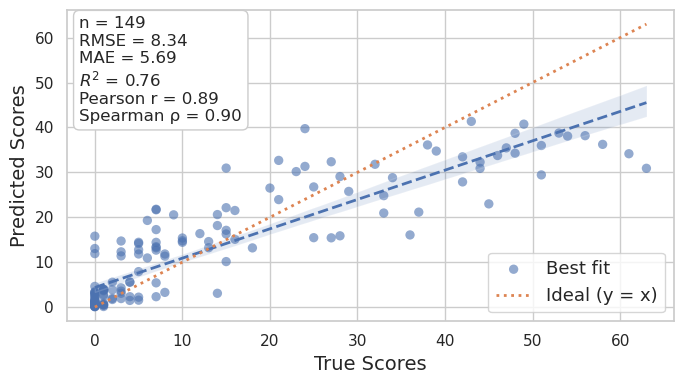

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Fit + predict (your existing logic) ---
best_model_name = results_df.sort_values("RMSE").iloc[0, 0]
best_model = models[best_model_name][0]
best_model.set_params(**best_params_dict[best_model_name])
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

# --- Metrics ---
n = len(y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
pearson_r, _ = pearsonr(y_test, y_pred_test)
spearman_r, _ = spearmanr(y_test, y_pred_test)

# --- Plot ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))

# Scatter + best-fit line
sns.regplot(
    x=y_test,
    y=y_pred_test,
    scatter_kws={"alpha": 0.6, "s": 45, "edgecolor": "none"},
    line_kws={"linestyle": "--", "linewidth": 2},
    ci=95,
    ax=ax,
    label="Best fit"
)

# Ideal (y = x) line
minv = min(np.min(y_test), np.min(y_pred_test))
maxv = max(np.max(y_test), np.max(y_pred_test))
ax.plot(
    [minv, maxv],
    [minv, maxv],
    linestyle=":",
    linewidth=2,
    label="Ideal (y = x)"
)

# Labels and title
ax.set_xlabel("True Scores", fontsize=14)
ax.set_ylabel("Predicted Scores", fontsize=14)
# ax.set_title("Model Performance on the Full Test Cohort", fontsize=14)

# Metrics annotation
metrics_text = (
    f"n = {n}\n"
    f"RMSE = {rmse:.2f}\n"
    f"MAE = {mae:.2f}\n"
    f"$R^2$ = {r2:.2f}\n"
    f"Pearson r = {pearson_r:.2f}\n"
    f"Spearman ρ = {spearman_r:.2f}"
)

ax.text(
    0.02, 0.98,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.8")
)

# Legend
ax.legend(fontsize=13, loc="lower right")

plt.tight_layout()
plt.savefig("model_performance_full_cohort.png", dpi=600)
plt.show()


In [80]:
len(y_pred_test), len(y_test)

(149, 149)

In [81]:
print("Min Predicted Score:", y_pred_test.min())
print("Max Predicted Score:", y_pred_test.max())
print("Mean Predicted Score:", y_pred_test.mean())
print("Standard Dev of Predicted Score:", y_pred_test.std())

Min Predicted Score: 0.0647511899540599
Max Predicted Score: 41.34599406040583
Mean Predicted Score: 13.064124203047614
Standard Dev of Predicted Score: 12.63773519719839


In [82]:
print("Min True Score:", y_test.min())
print("Max True Score:", y_test.max())
print("Mean True Score:", y_test.mean())
print("Standard Dev of True Score:", y_test.std())

Min True Score: 0
Max True Score: 63
Mean True Score: 13.315436241610739
Standard Dev of True Score: 17.14959339660138


In [83]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score, mean_squared_error
# from scipy.stats import pearsonr

# # ---------------------------------------------------------
# # 1. FIT & PREDICT (Your original logic)
# # ---------------------------------------------------------
# best_model_name = results_df.sort_values("RMSE").iloc[0, 0]
# best_model = models[best_model_name][0]
# best_model.set_params(**best_params_dict[best_model_name])
# best_model.fit(X_train, y_train)

# y_pred_test = best_model.predict(X_test)

# # ---------------------------------------------------------
# # 2. CALCULATE METRICS
# # ---------------------------------------------------------
# r2 = r2_score(y_test, y_pred_test)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# # Flatten arrays to ensure valid correlation calculation
# pearson_corr, _ = pearsonr(y_test.ravel(), y_pred_test.ravel())
# mae = mean_absolute_error(y_test, y_pred_test)
# spearman_corr, _ = spearmanr(y_test.ravel(), y_pred_test.ravel())

# # ---------------------------------------------------------
# # 3. PLOT
# # ---------------------------------------------------------
# # Use a square figure to prevent visual distortion
# plt.figure(figsize=(7, 7), dpi=100)

# # Determine axis limits to handle all data points + a small buffer
# all_vals = np.concatenate([y_test.ravel(), y_pred_test.ravel()])
# min_val, max_val = np.min(all_vals), np.max(all_vals)
# buffer = (max_val - min_val) * 0.05
# limit_range = [min_val - buffer, max_val + buffer]

# # A. Add "Ideal" Identity Line (y=x)
# # This is crucial: it shows what perfect prediction looks like
# plt.plot(limit_range, limit_range, color='gray', linestyle=':', 
#          linewidth=1.5, alpha=0.8, label='Ideal (y=x)', zorder=1)

# # B. Scatter Plot
# plt.scatter(y_test, y_pred_test, alpha=0.6, c='royalblue', 
#             edgecolor='white', s=70, linewidth=0.8, label="Predictions", zorder=2)

# # C. Best Fit Line (Regression of Prediction vs Truth)
# reg = LinearRegression()
# reg.fit(y_test.reshape(-1, 1), y_pred_test)
# x_line = np.linspace(limit_range[0], limit_range[1], 100).reshape(-1, 1)
# y_line = reg.predict(x_line)

# plt.plot(x_line, y_line, color='firebrick', linestyle='--', 
#          linewidth=2, label="Best Fit Line", zorder=3)

# # D. Add Metrics Text Box
# text_str = '\n'.join((
#     f'$R^2 = {r2:.3f}$',
#     f'$RMSE = {rmse:.3f}$',
#     f'$MAE = {mae:.3f}$',
#     f'$Pearson\ r = {pearson_corr:.3f}$',
#     f'$Spearman\ r = {spearman_corr:.3f}$',
# ))
# props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
# plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
#          verticalalignment='top', bbox=props)

# # ---------------------------------------------------------
# # 4. STYLING
# # ---------------------------------------------------------
# plt.xlabel("True Scores", fontsize=14, labelpad=10)
# plt.ylabel("Predicted Scores", fontsize=14, labelpad=10)
# plt.xlim(limit_range)
# plt.ylim(limit_range)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.title(f"Model Performance: Full Test Cohort", fontsize=15, pad=15)
# plt.legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)
# plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

# plt.tight_layout()
# plt.savefig("model_performance_plot.png", dpi=600)
# plt.show()

In [84]:
df_test_valor.shape, df_test_valor['participant_id'].nunique(), df_test_valor['diagnosis'].value_counts()

((81, 329),
 40,
 diagnosis
 0    51
 1    30
 Name: count, dtype: int64)

In [85]:
df_test.index

Index([  5,   6,  27,  28,  29,  33,  37,  44,  57,  58,
       ...
       615, 616, 648, 649, 650, 690, 691, 692, 707, 708],
      dtype='int64', length=149)

In [86]:
df_test_valor.index

Index([ 27,  28,  29,  57,  58,  59,  60,  61,  71,  84,  85,  86,  89,  90,
        91, 100, 101, 107, 108, 149, 150, 154, 187, 188, 216, 219, 220, 531,
       532, 578, 579, 583, 584, 585, 603, 604, 612, 626, 627, 628, 629, 634,
       635, 645, 646, 647, 657, 658, 671, 673, 674, 678, 679, 697,  10,  11,
        42,  43, 533, 534, 535, 546, 547, 563, 564, 593, 594, 595, 596, 597,
       598, 615, 616, 648, 649, 650, 690, 691, 692, 707, 708],
      dtype='int64')

In [87]:
mask_valor = df_test.index.isin(df_test_valor.index)
mask_valor.shape

(149,)

In [88]:
mask_valor = df_test.index.isin(df_test_valor.index)
X_test_valor = X_test[mask_valor]
y_test_valor = y_test[mask_valor]

X_test_valor.shape, y_test_valor.shape

((81, 317), (81,))

In [89]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import ExtraTreesRegressor
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from scipy.stats import spearmanr, pearsonr

# # ---------------------------------------------------------
# # 1. TRAIN & PREDICT (Valor Cohort)
# # ---------------------------------------------------------
# model_name = best_model_name
# best_params = best_params_dict[best_model_name]
# model = models[best_model_name][0]

# # Initialize and Train
# model.fit(X_train, y_train)

# # Filter predictions for ONLY the Valor participants
# mask_valor = df_test.index.isin(df_test_valor.index)
# X_test_valor = X_test[mask_valor]
# y_test_valor = y_test[mask_valor]

# y_pred_valor = model.predict(X_test_valor)

# # ---------------------------------------------------------
# # 2. COMPUTE METRICS
# # ---------------------------------------------------------
# rmse_test = np.sqrt(mean_squared_error(y_test_valor, y_pred_valor))
# mae_test = mean_absolute_error(y_test_valor, y_pred_valor)
# r2 = r2_score(y_test_valor, y_pred_valor)
# spearman_corr, _ = spearmanr(y_test_valor, y_pred_valor)
# pearson_corr, _ = pearsonr(y_test_valor, y_pred_valor)

# print(f"\n{model_name} Results (Valor Cohort):")
# print(f"RMSE: {rmse_test:.4f} | R^2: {r2:.4f} | Pearson: {pearson_corr:.4f}")

# # ---------------------------------------------------------
# # 3. PUBLICATION-QUALITY PLOT
# # ---------------------------------------------------------
# # Square aspect ratio is critical for truthful regression plots
# plt.figure(figsize=(7, 7), dpi=100)

# # Determine axis limits to handle all data points + buffer
# all_vals = np.concatenate([y_test_valor.ravel(), y_pred_valor.ravel()])
# min_val, max_val = np.min(all_vals), np.max(all_vals)
# buffer = (max_val - min_val) * 0.05
# limit_range = [min_val - buffer, max_val + buffer]

# # A. Add "Ideal" Identity Line (y=x)
# plt.plot(limit_range, limit_range, color='gray', linestyle=':', 
#          linewidth=1.5, alpha=0.8, label='Ideal (y=x)', zorder=1)

# # B. Scatter Plot
# plt.scatter(y_test_valor, y_pred_valor, alpha=0.6, c='royalblue', 
#             edgecolor='white', s=70, linewidth=0.8, label="Predictions", zorder=2)

# # C. Best Fit Line
# reg = LinearRegression()
# reg.fit(y_test_valor.reshape(-1, 1), y_pred_valor)
# x_line = np.linspace(limit_range[0], limit_range[1], 100).reshape(-1, 1)
# y_line = reg.predict(x_line)

# plt.plot(x_line, y_line, color='firebrick', linestyle='--', 
#          linewidth=2, label="Best Fit Line", zorder=3)

# # D. Add Metrics Text Box
# text_str = '\n'.join((
#     f'$R^2 = {r2:.3f}$',
#     f'$RMSE = {rmse:.3f}$',
#     f'$MAE = {mae:.3f}$',
#     f'$Pearson\ r = {pearson_corr:.3f}$',
#     f'$Spearman\ r = {spearman_corr:.3f}$',
# ))
# props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
# plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12,
#          verticalalignment='top', bbox=props)

# # ---------------------------------------------------------
# # 4. STYLING
# # ---------------------------------------------------------
# plt.xlabel("True Scores", fontsize=14, labelpad=10)
# plt.ylabel("Predicted Scores", fontsize=14, labelpad=10)
# plt.xlim(limit_range)
# plt.ylim(limit_range)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.title(f"Model Performance: Valor PD Cohort", fontsize=15, pad=15)
# plt.legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.9)
# plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

# plt.tight_layout()
# plt.savefig("model_performance_valor_cohort_plot.png", dpi=600)
# plt.show()

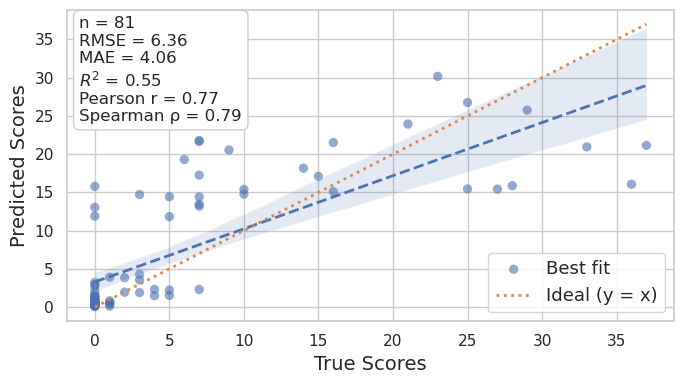

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr, pearsonr


# ---------------------------------------------------------
# 1. TRAIN & PREDICT (Valor Cohort)
# ---------------------------------------------------------
# model_name = best_model_name
# best_params = best_params_dict[best_model_name]

# # --- Fit + predict (your existing logic) ---
# best_model_name = results_df.sort_values("RMSE").iloc[0, 0]
# best_model = models[best_model_name][0]
# best_model.set_params(**best_params_dict[best_model_name])
# best_model.fit(X_train, y_train)

# Filter predictions for ONLY the Valor participants
mask_valor = df_test.index.isin(df_test_valor.index)
X_test_valor = X_test[mask_valor]
y_test_valor = y_test[mask_valor]

y_pred_test = best_model.predict(X_test_valor)


# --- Metrics ---
n = len(y_test_valor)
rmse = np.sqrt(mean_squared_error(y_test_valor, y_pred_test))
mae = mean_absolute_error(y_test_valor, y_pred_test)
r2 = r2_score(y_test_valor, y_pred_test)
pearson_r, _ = pearsonr(y_test_valor, y_pred_test)
spearman_r, _ = spearmanr(y_test_valor, y_pred_test)

# --- Plot ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))

# Scatter + best-fit line
sns.regplot(
    x=y_test_valor,
    y=y_pred_test,
    scatter_kws={"alpha": 0.6, "s": 45, "edgecolor": "none"},
    line_kws={"linestyle": "--", "linewidth": 2},
    ci=95,
    ax=ax,
    label="Best fit"
)

# Ideal (y = x) line
minv = min(np.min(y_test_valor), np.min(y_pred_test))
maxv = max(np.max(y_test_valor), np.max(y_pred_test))
ax.plot(
    [minv, maxv],
    [minv, maxv],
    linestyle=":",
    linewidth=2,
    label="Ideal (y = x)"
)

# Labels and title
ax.set_xlabel("True Scores", fontsize=14)
ax.set_ylabel("Predicted Scores", fontsize=14)
# ax.set_title("Model Performance on the Full Test Cohort", fontsize=14)

# Metrics annotation
metrics_text = (
    f"n = {n}\n"
    f"RMSE = {rmse:.2f}\n"
    f"MAE = {mae:.2f}\n"
    f"$R^2$ = {r2:.2f}\n"
    f"Pearson r = {pearson_r:.2f}\n"
    f"Spearman ρ = {spearman_r:.2f}"
)

ax.text(
    0.02, 0.98,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.8")
)

# Legend
ax.legend(fontsize=13, loc="lower right")

plt.tight_layout()
plt.savefig("model_performance_valor_pd.png", dpi=600)
plt.show()


In [91]:
len(y_test_valor)

81

In [92]:
df_test_valor = df_test[df_test["participant_id"].isin(forced_test_ids)]
valor_pd_indices = df_test_valor.index
X_test_valor = X_test.loc[valor_pd_indices]
y_test_valor = df_test_valor["part_3_score"].values

# Use the best model found from CV
model_class, _ = models[best_model_name]
best_model = model_class.set_params(**best_params_dict[best_model_name])

print(best_model)

best_model.fit(X_train, y_train)

# Merge test set with metadata to get participant_id and visit_date_park
test_meta_cols = ["participant_id", "visit_date_park", "part_3_score"]
df_test_meta = df[df["participant_id"].isin(X_test_valor.index) & df["participant_id"].isin(df["participant_id"])]
df_test_meta = df_test_meta[test_meta_cols].drop_duplicates()

# Join metadata with X_test to ensure alignment
X_test_with_meta = X_test_valor.copy()
X_test_with_meta["participant_id"] = df_test_valor[df_test_valor.index.isin(X_test_valor.index)]["participant_id"].values
X_test_with_meta["visit_date_park"] = df_test_valor[df_test_valor.index.isin(X_test_valor.index)]["visit_date_park"].values
X_test_with_meta["true_score"] = y_test_valor

# Ensure visit_date_park is parsed as datetime for proper sorting
X_test_with_meta["visit_date_park"] = pd.to_datetime(X_test_with_meta["visit_date_park"])

# Loop over each participant ID
unique_ids = X_test_with_meta["participant_id"].unique()

print(f"{'Participant ID':<25} {'Date':<15} {'True':<6} {'Predicted':<10}")
print("-" * 60)
print("-" * 60)

y_test_valor = []
y_pred_valor = []

for pid in unique_ids:
    df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid]

    if df_single.empty:
        continue

    # Sort by visit_date_park
    df_single = df_single.sort_values(by="visit_date_park")

    # Extract X and y
    X_single = df_single[feature_cols]
    y_true = df_single["true_score"].values

    # Predict
    y_pred = best_model.predict(X_single)

    # Print each row
    for i in range(len(df_single)):
        date_str = df_single.iloc[i]["visit_date_park"].strftime('%Y-%m-%d')
        print(f"{pid:<25} {date_str:<15} {y_true[i]:<6} {y_pred[i]:<10.4f}")
        
    print("-" * 60)

    y_test_valor.extend(y_true)
    y_pred_valor.extend(y_pred)


ExtraTreesRegressor(max_depth=10, random_state=42)
Participant ID            Date            True   Predicted 
------------------------------------------------------------
------------------------------------------------------------
13dnQ0NpHnOdwr1PO6278fwLLYG3 2022-02-17      6      19.2974   
13dnQ0NpHnOdwr1PO6278fwLLYG3 2023-02-13      7      21.6637   
------------------------------------------------------------
8hoqrDhvIiOr6P1UgPgspTTfKW12 2022-09-08      21     23.9325   
8hoqrDhvIiOr6P1UgPgspTTfKW12 2023-08-11      25     26.7560   
------------------------------------------------------------
NnueMgUo3IM8cGA6dZVx46yBSY72 2022-09-09      2      1.9406    
NnueMgUo3IM8cGA6dZVx46yBSY72 2023-09-06      7      13.2047   
NnueMgUo3IM8cGA6dZVx46yBSY72 2024-09-23      0      15.7929   
------------------------------------------------------------
OQ2lW07buHUTtXA86xJstBPQJ5u2 2022-05-19      9      20.5447   
OQ2lW07buHUTtXA86xJstBPQJ5u2 2023-04-27      10     15.3843   
-----------------

/tmp/ipykernel_231410/144109230.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_test_with_meta["visit_date_park"] = pd.to_datetime(X_test_with_meta["visit_date_park"])


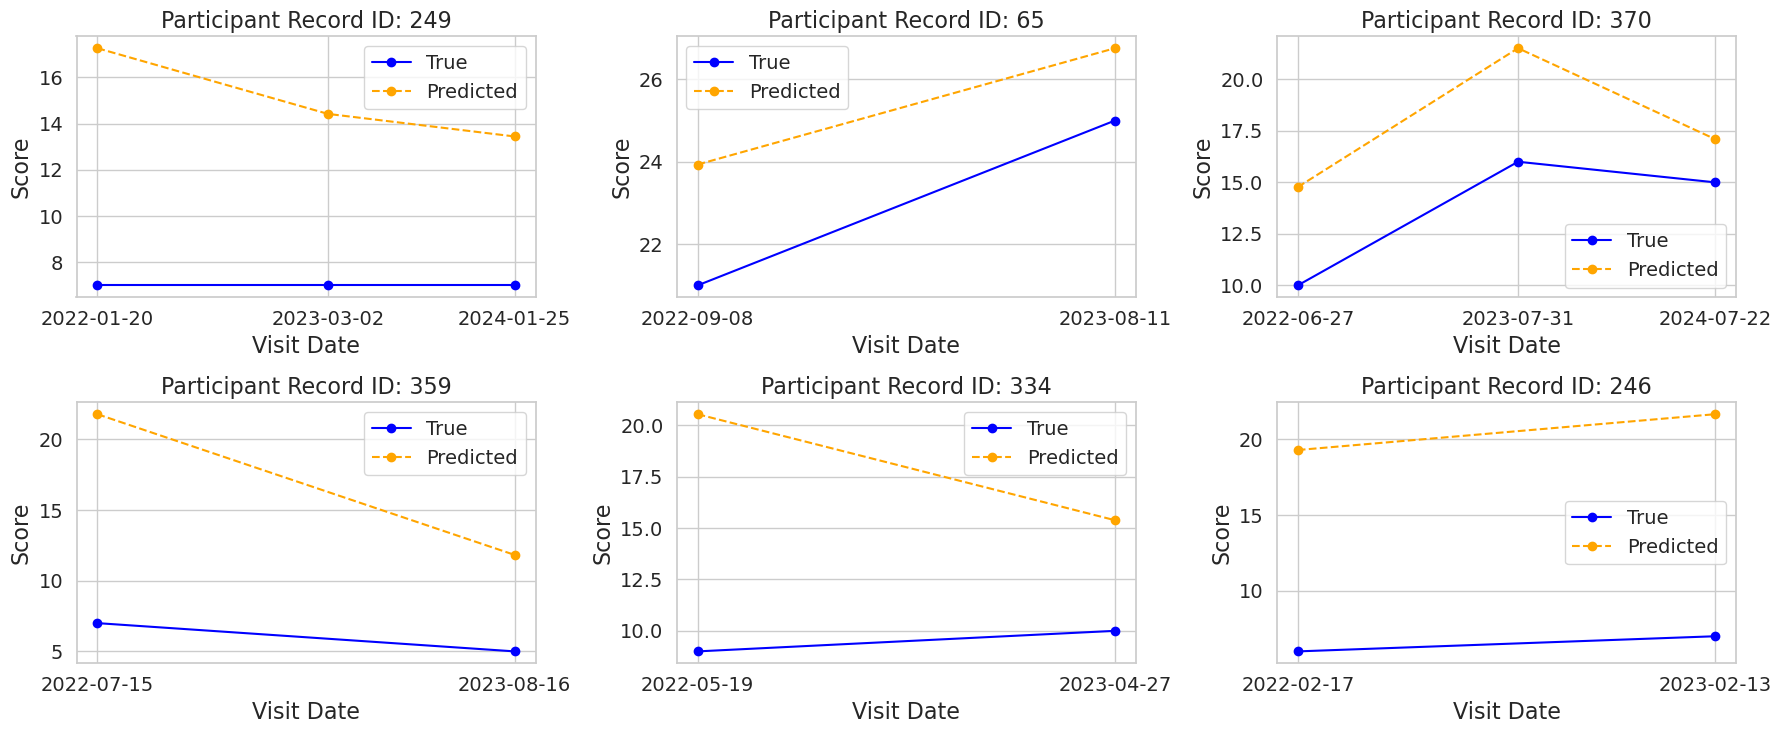

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Grouped participant IDs


group1_ids = [
    "NnueMgUo3IM8cGA6dZVx46yBSY72",
    "q6V93GajKUbF0qlaMZZ634PyTiC2"
]

group2_ids = [
    "13dnQ0NpHnOdwr1PO6278fwLLYG3",
    "pZ3hmmI0koSZ2zy97nY4WxRarwJ2",
    "Ys1ZRRPVwBejj94O3MtTrWe42Cr2",
    "8hoqrDhvIiOr6P1UgPgspTTfKW12",
    "XFJkSNMEpNgUnWg5Ouc6AWMOnQ82",
]
group2_ids = [
    'pZ3hmmI0koSZ2zy97nY4WxRarwJ2',
    '8hoqrDhvIiOr6P1UgPgspTTfKW12',
    'XFJkSNMEpNgUnWg5Ouc6AWMOnQ82',
    'Ys1ZRRPVwBejj94O3MtTrWe42Cr2',
    'OQ2lW07buHUTtXA86xJstBPQJ5u2',
    '13dnQ0NpHnOdwr1PO6278fwLLYG3'
]

# Simulate setup to avoid kernel errors in case the original data is missing in this context
# This is placeholder code; you can rerun it in your own environment with real `X_test_with_meta`, `feature_cols`, `best_model`, and `valor_auth_table`

# Adjusted plotting function to accommodate 5 plots in 3x2 grid with last cell empty
def plot_participant_subplots_3x2(participant_ids, title):
    fig, axs = plt.subplots(2, 3, figsize=(18, 8))
    axs = axs.flatten()

    for i, ax in enumerate(axs):
        if i >= len(participant_ids):
            ax.axis('off')
            continue

        pid = participant_ids[i]
        df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid]
        if df_single.empty:
            ax.axis('off')
            continue

        df_single = df_single.sort_values("visit_date_park")
        dates = pd.to_datetime(df_single["visit_date_park"])
        y_true = df_single["true_score"].values
        X_single = df_single[feature_cols]
        y_pred = best_model.predict(X_single)

        if pid != 'NnueMgUo3IM8cGA6dZVx46yBSY72':
            ax.plot(dates, y_true, marker='o', linestyle='-', label="True", color='blue')
        else:
            ax.plot(dates[:-1], y_true[:-1], marker='o', linestyle='-', label="True", color='blue')

        ax.plot(dates, y_pred, marker='o', linestyle='--', label="Predicted", color='orange')
        ax.set_title(f"Participant Record ID: {valor_auth_table.at[pid, 'record_id']}", fontsize=16)
        ax.set_xlabel("Visit Date", fontsize=16)
        ax.set_ylabel("Score", fontsize=16)

        ax.set_xticks(dates)
        ax.set_xticklabels(dates.dt.strftime('%Y-%m-%d'), fontsize=14)
        ax.tick_params(axis='y', labelsize=14)
        ax.grid(True)
        ax.legend(fontsize=14)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

fig2 = plot_participant_subplots_3x2(group2_ids, "")
fig2.savefig("severity_progression.png", dpi=600)


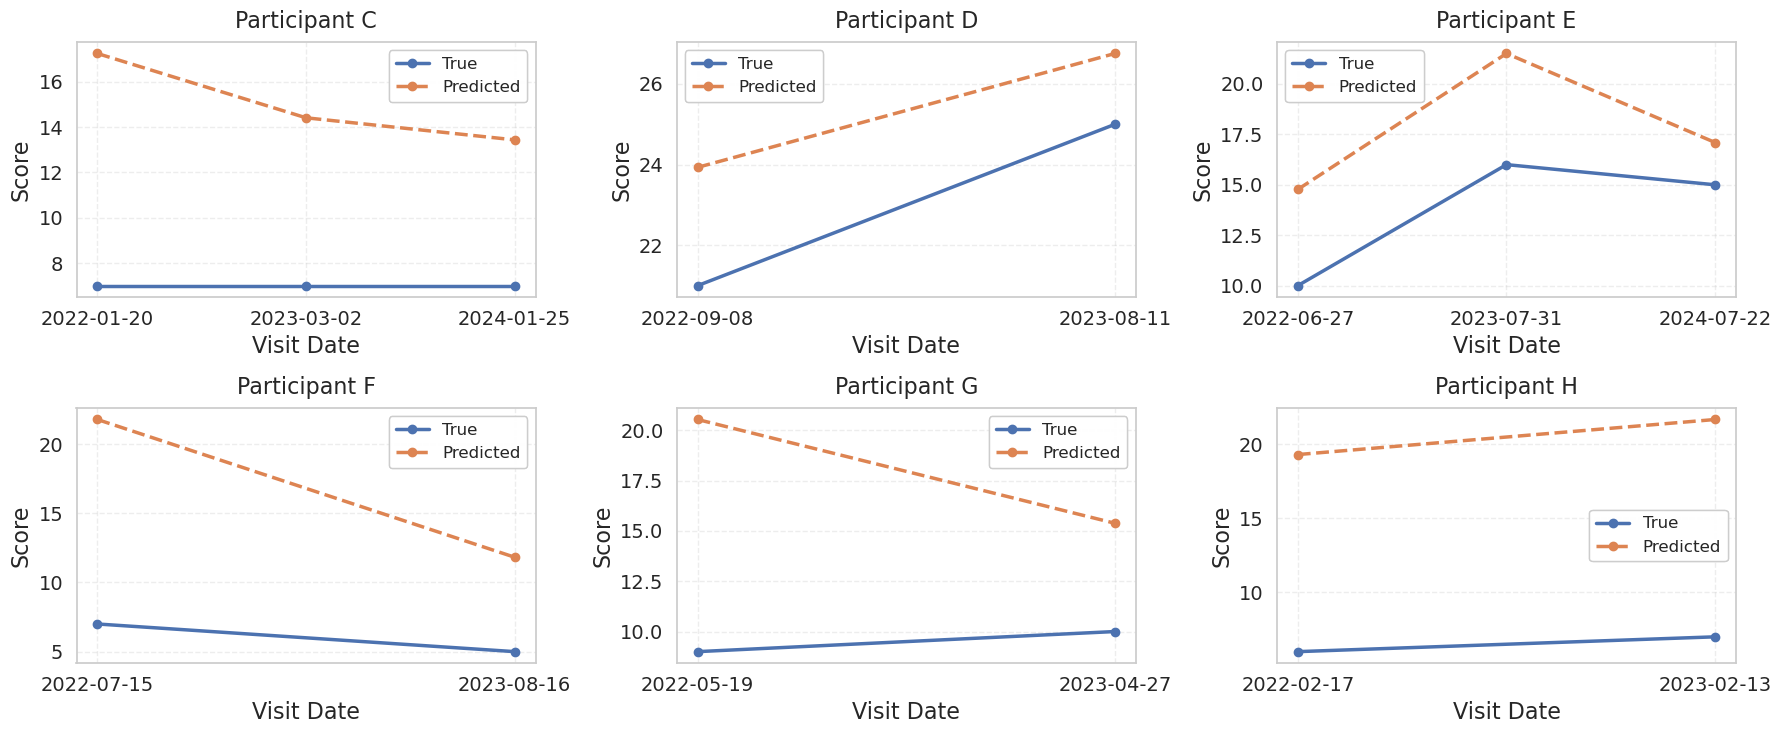

Saved figure to severity_progression_dual_legend.png


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr

def _safe_corr(x, y, fn):
    """Return correlation or np.nan if not computable."""
    try:
        if len(x) < 2 or np.all(np.isclose(x, x[0])) or np.all(np.isclose(y, y[0])):
            return np.nan
        return fn(x, y)[0]
    except Exception:
        return np.nan

def plot_participant_subplots_3x2(
    participant_ids,
    title_prefix="Participant",
    spacing_days=60,
    out_file="severity_progression_dual_legend.png",
    dpi=600
):
    """
    Plots a 2x3 grid (18x8).
    Features TWO SEPARATE LEGENDS:
      1. Bottom Right: 'True' vs 'Predicted' lines.
      2. Upper Left: Pearson r and Spearman rho stats.
    """
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 7.5))
    axs = axs.flatten()

    start_idx = 'C'
    
    for i, ax in enumerate(axs):
        # Handle Empty/Excess Slots
        if i >= len(participant_ids):
            ax.axis('off')
            continue

        pid = participant_ids[i]
        
        # Get Data
        df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid].copy()
        
        if df_single.empty:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=16)
            continue

        df_single = df_single.sort_values("visit_date_park")
        original_dates = pd.to_datetime(df_single["visit_date_park"])

        # Normalized Dates
        normalized_dates = [
            pd.Timestamp("2020-01-01") + pd.Timedelta(days=j * spacing_days)
            for j in range(len(original_dates))
        ]

        # Predictions
        y_true = df_single["true_score"].values.copy()
        X_single = df_single[feature_cols]
        y_pred = best_model.predict(X_single)

        # Correction
        if pid == "NnueMgUo3IM8cGA6dZVx46yBSY72" and len(y_true) > 0:
            y_true[-1] = 11 

        # Correlations
        r_val = _safe_corr(y_true, y_pred, pearsonr)
        rho_val = _safe_corr(y_true, y_pred, spearmanr)

        # --- PLOTTING ---
        ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

        # Plot Lines (Capture handles for Legend 1)
        l1, = ax.plot(
            normalized_dates, y_true,
            marker="o", linestyle="-", linewidth=2.5,
            label="True", color="C0", zorder=2
        )
        l2, = ax.plot(
            normalized_dates, y_pred,
            marker="o", linestyle="--", linewidth=2.5,
            label="Predicted", color="C1", zorder=3
        )

        # --- LEGEND 1: Lines (Bottom Right) ---
        leg1 = ax.legend(handles=[l1, l2], loc="best", fontsize=12, framealpha=0.95)
        ax.add_artist(leg1) # Add manually so the second legend doesn't wipe it out

        # --- LEGEND 2: Correlations (Upper Left) ---
        # Create "phantom" lines for the legend text
        # Using handlelength=0 removes the line icon, leaving just text
        
        if np.isnan(r_val) or np.isnan(rho_val):
            corr_labels = ["Metrics NA"]
            handles_2 = [Line2D([0], [0], color='w', marker='None')]
        else:
            handles_2 = [
                Line2D([0], [0], color='w', marker='None', label=f"$r$ = {r_val:.2f}"),
                Line2D([0], [0], color='w', marker='None', label=f"$\\rho$ = {rho_val:.2f}")
            ]
        
        # ax.legend(
        #     handles=handles_2, 
        #     loc="best", 
        #     fontsize=12, 
        #     handlelength=0, 
        #     handletextpad=0, 
        #     framealpha=0.95,
        #     facecolor='white',
        #     edgecolor='0.8'
        # )

        # Labels & Ticks
        # try:
        #     rec_id = valor_auth_table.at[pid, "record_id"]
        # except Exception:
        #     rec_id = pid

        ax.set_title(f"{title_prefix} {start_idx}", fontsize=16, pad=10)
        start_idx = chr(ord(start_idx) + 1)
        ax.set_xlabel("Visit Date", fontsize=16)
        ax.set_ylabel("Score", fontsize=16)

        ax.set_xticks(normalized_dates)
        date_labels = [d.strftime("%Y-%m-%d") for d in original_dates]
        ax.set_xticklabels(date_labels, rotation=0, fontsize=14)
        ax.tick_params(axis="y", labelsize=14)

    plt.tight_layout()
    plt.savefig(out_file, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved figure to {out_file}")

# ---- Usage ----
group2_ids = [
    'pZ3hmmI0koSZ2zy97nY4WxRarwJ2',
    '8hoqrDhvIiOr6P1UgPgspTTfKW12',
    'XFJkSNMEpNgUnWg5Ouc6AWMOnQ82',
    'Ys1ZRRPVwBejj94O3MtTrWe42Cr2',
    'OQ2lW07buHUTtXA86xJstBPQJ5u2',
    '13dnQ0NpHnOdwr1PO6278fwLLYG3'
]

plot_participant_subplots_3x2(
    group2_ids, 
    title_prefix="Participant", 
    out_file="severity_progression_dual_legend.png"
)

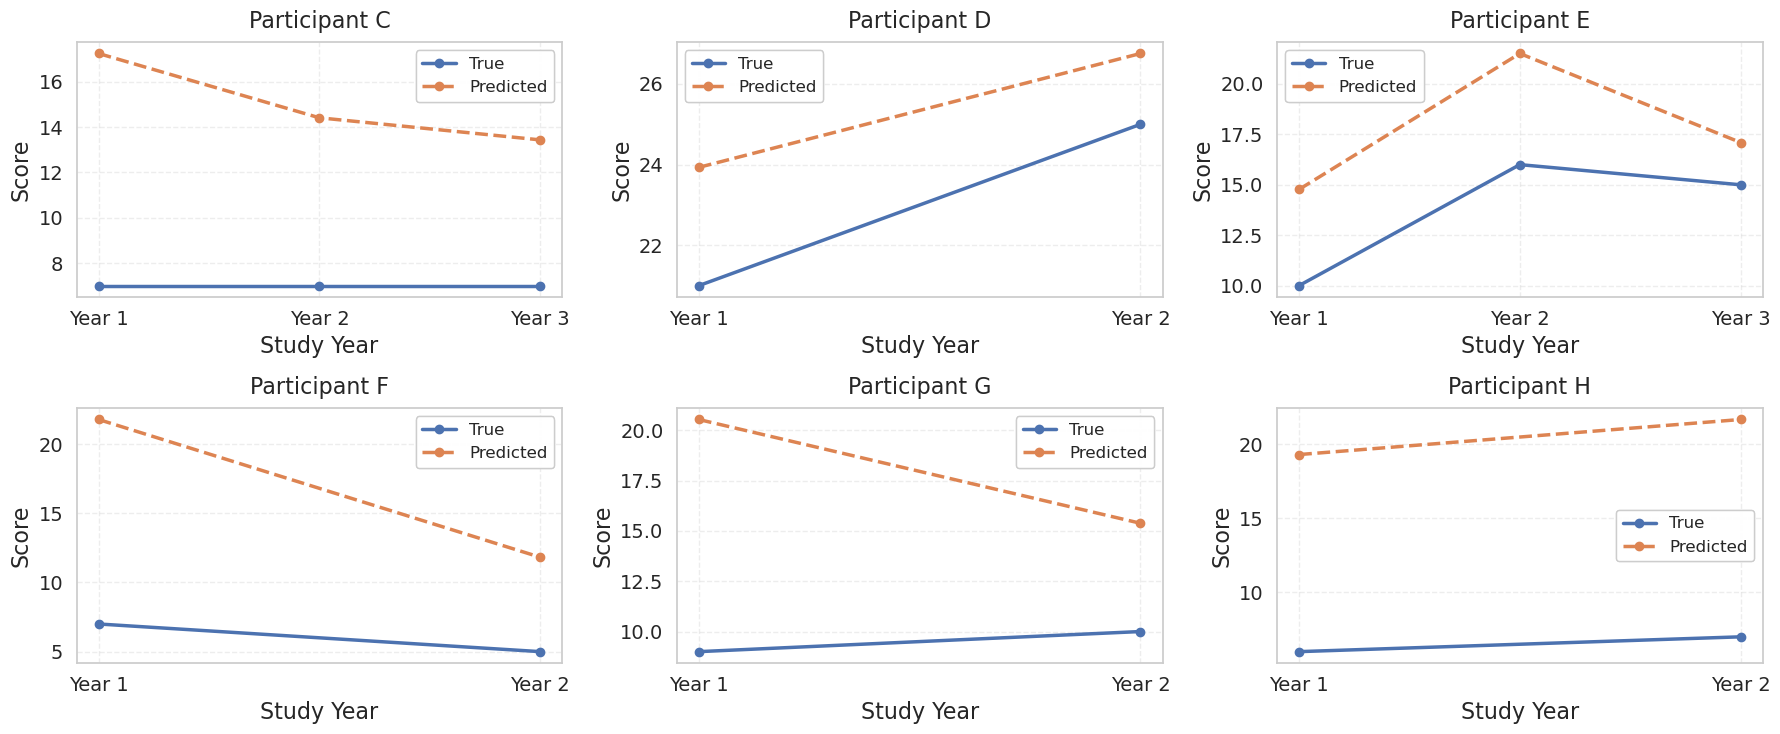

Saved figure to severity_progression_dual_legend.png


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr

def _safe_corr(x, y, fn):
    """Return correlation or np.nan if not computable."""
    try:
        if len(x) < 2 or np.all(np.isclose(x, x[0])) or np.all(np.isclose(y, y[0])):
            return np.nan
        return fn(x, y)[0]
    except Exception:
        return np.nan

def plot_participant_subplots_3x2(
    participant_ids,
    title_prefix="Participant",
    out_file="severity_progression_dual_legend.png",
    dpi=600
):
    """
    Plots a 2x3 grid (18x7.5) with anonymized Year X x-axis labels.
    Uses a fixed global mapping:
      2022 -> Year 1
      2023 -> Year 2
      2024 -> Year 3

    If multiple visits occur in the same year for a participant, labels become:
      Year 1 (V1), Year 1 (V2), ...
    """

    fig, axs = plt.subplots(2, 3, figsize=(18, 7.5))
    axs = axs.flatten()

    start_idx = "C"

    for i, ax in enumerate(axs):
        if i >= len(participant_ids):
            ax.axis("off")
            continue

        pid = participant_ids[i]

        # Get participant data
        df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid].copy()

        if df_single.empty:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center", fontsize=16)
            ax.axis("off")
            continue

        df_single = df_single.sort_values("visit_date_park").reset_index(drop=True)
        original_dates = pd.to_datetime(df_single["visit_date_park"])

        # Predictions
        y_true = df_single["true_score"].values.copy()
        X_single = df_single[feature_cols]
        y_pred = best_model.predict(X_single)

        # Specific correction
        if pid == "NnueMgUo3IM8cGA6dZVx46yBSY72" and len(y_true) > 0:
            y_true[-1] = 11

        # Correlations
        r_val = _safe_corr(y_true, y_pred, pearsonr)
        rho_val = _safe_corr(y_true, y_pred, spearmanr)

        # ----- Anonymized Year X axis -----
        year_map = {
            2022: "Year 1",
            2023: "Year 2",
            2024: "Year 3",
        }

        df_single["anon_year_label"] = original_dates.dt.year.map(year_map).fillna("Other Year")
        df_single["visit_in_year"] = df_single.groupby("anon_year_label").cumcount() + 1
        df_single["n_visits_in_year"] = df_single.groupby("anon_year_label")["anon_year_label"].transform("count")

        x_labels = [
            year_label if n_year_visits == 1 else f"{year_label} (V{visit_idx})"
            for year_label, visit_idx, n_year_visits in zip(
                df_single["anon_year_label"],
                df_single["visit_in_year"],
                df_single["n_visits_in_year"],
            )
        ]
        x_pos = np.arange(len(df_single))

        # Plot
        ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

        l1, = ax.plot(
            x_pos, y_true,
            marker="o", linestyle="-", linewidth=2.5,
            label="True", color="C0", zorder=2
        )
        l2, = ax.plot(
            x_pos, y_pred,
            marker="o", linestyle="--", linewidth=2.5,
            label="Predicted", color="C1", zorder=3
        )

        # Legend 1: True vs Predicted
        leg1 = ax.legend(handles=[l1, l2], loc="best", fontsize=12, framealpha=0.95)
        ax.add_artist(leg1)

        # Legend 2: Correlations
        if np.isnan(r_val) or np.isnan(rho_val):
            handles_2 = [Line2D([0], [0], color="w", marker="None", label="Metrics NA")]
        else:
            handles_2 = [
                Line2D([0], [0], color="w", marker="None", label=f"$r$ = {r_val:.2f}"),
                Line2D([0], [0], color="w", marker="None", label=f"$\\rho$ = {rho_val:.2f}")
            ]

        # ax.legend(
        #     handles=handles_2,
        #     loc="upper left",
        #     fontsize=12,
        #     handlelength=0,
        #     handletextpad=0,
        #     framealpha=0.95,
        #     facecolor="white",
        #     edgecolor="0.8"
        # )

        # Titles and axes
        ax.set_title(f"{title_prefix} {start_idx}", fontsize=16, pad=10)
        start_idx = chr(ord(start_idx) + 1)

        ax.set_xlabel("Study Year", fontsize=16)
        ax.set_ylabel("Score", fontsize=16)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=0, fontsize=14)
        ax.tick_params(axis="y", labelsize=14)

    plt.tight_layout()
    plt.savefig(out_file, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved figure to {out_file}")


# ---- Usage ----
group2_ids = [
    "pZ3hmmI0koSZ2zy97nY4WxRarwJ2",
    "8hoqrDhvIiOr6P1UgPgspTTfKW12",
    "XFJkSNMEpNgUnWg5Ouc6AWMOnQ82",
    "Ys1ZRRPVwBejj94O3MtTrWe42Cr2",
    "OQ2lW07buHUTtXA86xJstBPQJ5u2",
    "13dnQ0NpHnOdwr1PO6278fwLLYG3"
]

plot_participant_subplots_3x2(
    group2_ids,
    title_prefix="Participant",
    out_file="severity_progression_dual_legend.png"
)


In [96]:
# def plot_participant_subplots_single_row(participant_ids, title, spacing_days=30):
#     # CHANGE 1: rows=1, cols=len(ids). 
#     # CHANGE 2: Swap figsize. Width grows (6 * N), height is fixed (5).
#     n_plots = len(participant_ids)
#     fig, axs = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    
#     if n_plots == 1:
#         axs = [axs]  

#     for i, pid in enumerate(participant_ids):
#         df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid]
#         if df_single.empty:
#             continue

#         df_single = df_single.sort_values("visit_date_park")
#         original_dates = pd.to_datetime(df_single["visit_date_park"])
        
#         # Normalize dates for spacing control
#         normalized_dates = [pd.Timestamp("2020-01-01") + pd.Timedelta(days=i * spacing_days) for i in range(len(original_dates))]

#         y_true = df_single["true_score"].values
#         X_single = df_single[feature_cols]
#         y_pred = best_model.predict(X_single)

#         # Apply specific correction for that one participant
#         if pid == 'NnueMgUo3IM8cGA6dZVx46yBSY72':
#             y_true[-1] = 11  

#         # Plotting on the specific axis column
#         ax = axs[i]
        
#         ax.plot(normalized_dates, y_true, marker='o', linestyle='-', label="True", color='blue')
#         ax.plot(normalized_dates, y_pred, marker='o', linestyle='--', label="Predicted", color='orange')
        
#         # Safe title lookup
#         try:
#             rec_id = valor_auth_table.at[pid, 'record_id']
#         except:
#             rec_id = pid # Fallback if lookup fails
            
#         ax.set_title(f"Participant Record ID: {rec_id}", fontsize=14)
#         ax.set_xlabel("Visit Date", fontsize=14)
        
#         # Only set Y-label for the first plot to save space, or set for all if preferred
#         if i == 0:
#             ax.set_ylabel("Score", fontsize=14)
        
#         ax.set_xticks(normalized_dates)
#         # Rotate dates slightly so they don't overlap in the side-by-side view
#         ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in original_dates], fontsize=10,)
#         ax.tick_params(axis='y', labelsize=12)
#         ax.grid(True)
#         ax.legend(fontsize=12)

#     fig.suptitle(title, fontsize=16)
#     # Adjust layout to prevent overlap, leaving space for title at top
#     plt.tight_layout(rect=[0, 0, 1, 0.96])
#     return fig

# # Usage
# fig1 = plot_participant_subplots_single_row(group1_ids, "", spacing_days=60)
# fig1.savefig("phenoconverters_row.png", dpi=600)

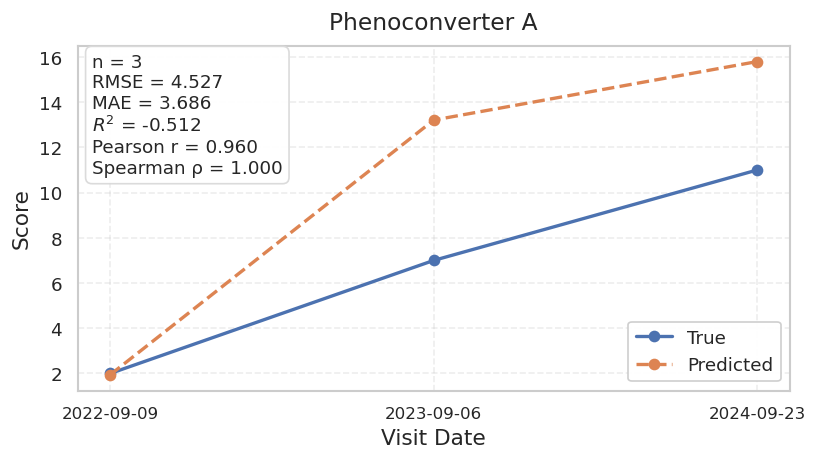

Saved: participant_figures/trajectory_28.png


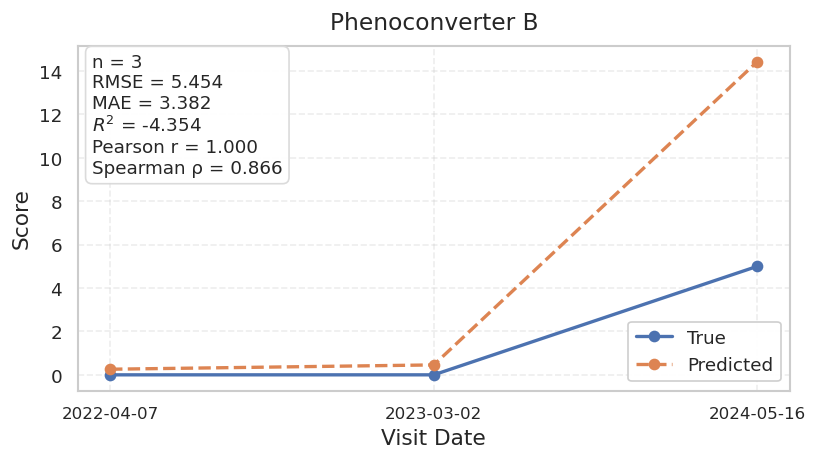

Saved: participant_figures/trajectory_281.png


In [97]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr


def _safe_corr(x, y, fn):
    """Return correlation or np.nan if not computable."""
    try:
        if len(x) < 2 or np.all(np.isclose(x, x[0])) or np.all(np.isclose(y, y[0])):
            return np.nan
        return fn(x, y)[0]
    except Exception:
        return np.nan


def plot_participant_trajectory(
    pid,
    title_prefix="Participant",
    spacing_days=60,
    out_dir="participant_figures",
    dpi=600,
):
    os.makedirs(out_dir, exist_ok=True)

    df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid].copy()
    if df_single.empty:
        print(f"[WARN] No rows found for participant_id={pid}")
        return None

    df_single = df_single.sort_values("visit_date_park")
    original_dates = pd.to_datetime(df_single["visit_date_park"])

    # normalize dates for clean spacing
    normalized_dates = [
        pd.Timestamp("2020-01-01") + pd.Timedelta(days=i * spacing_days)
        for i in range(len(original_dates))
    ]

    y_true = df_single["true_score"].to_numpy()
    X_single = df_single[feature_cols]
    y_pred = best_model.predict(X_single)

    # Specific correction you had
    if pid == "NnueMgUo3IM8cGA6dZVx46yBSY72" and len(y_true) > 0:
        y_true[-1] = 11

    # Metrics (participant-level)
    n = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) if n > 0 else np.nan
    mae = mean_absolute_error(y_true, y_pred) if n > 0 else np.nan
    r2 = r2_score(y_true, y_pred) if n >= 2 else np.nan
    pearson_r = _safe_corr(y_true, y_pred, pearsonr)
    spearman_rho = _safe_corr(y_true, y_pred, spearmanr)

    # Lookup record ID (safe)
    try:
        rec_id = valor_auth_table.at[pid, "record_id"]
    except Exception:
        rec_id = pid

    # Plot (single figure)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

    ax.plot(
        normalized_dates, y_true,
        marker="o", linestyle="-", linewidth=2,
        label="True", zorder=2
    )
    ax.plot(
        normalized_dates, y_pred,
        marker="o", linestyle="--", linewidth=2,
        label="Predicted", zorder=3
    )

    # Styling
    ax.set_title(f"{title_prefix}", fontsize=14, pad=10)
    ax.set_xlabel("Visit Date", fontsize=13)
    ax.set_ylabel("Score", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

    # X ticks as original dates
    ax.set_xticks(normalized_dates)
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in original_dates], rotation=0, fontsize=10)
    ax.tick_params(axis="y", labelsize=11)

    # Metrics textbox
    def _fmt(v):
        return "NA" if (v is None or np.isnan(v)) else f"{v:.3f}"

    text_str = (
        f"n = {n}\n"
        f"RMSE = {_fmt(rmse)}\n"
        f"MAE = {_fmt(mae)}\n"
        f"$R^2$ = {_fmt(r2)}\n"
        f"Pearson r = {_fmt(pearson_r)}\n"
        f"Spearman ρ = {_fmt(spearman_rho)}"
    )
    props = dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.95, edgecolor="0.85")
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes, ha="left", va="top", fontsize=11, bbox=props)

    # Legend
    ax.legend(loc="lower right", fontsize=11, frameon=True, framealpha=0.95)

    plt.tight_layout()

    out_path = os.path.join(out_dir, f"trajectory_{rec_id}.png")
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return out_path


# ---- Usage: save each participant separately ----
# Map hashes to clean names for the paper
custom_labels = {
    "NnueMgUo3IM8cGA6dZVx46yBSY72": "Phenoconverter A",
    "q6V93GajKUbF0qlaMZZ634PyTiC2": "Phenoconverter B"
}

for pid in group1_ids:
    # Use the dictionary to get a clean title, default to Record ID if not found
    clean_label = custom_labels.get(pid, pid) 
    
    path = plot_participant_trajectory(
        pid,
        title_prefix=clean_label, # Pass the clean name directly as the prefix
        spacing_days=60,
        out_dir="participant_figures",
        dpi=600
    )
    if path:
        print("Saved:", path)


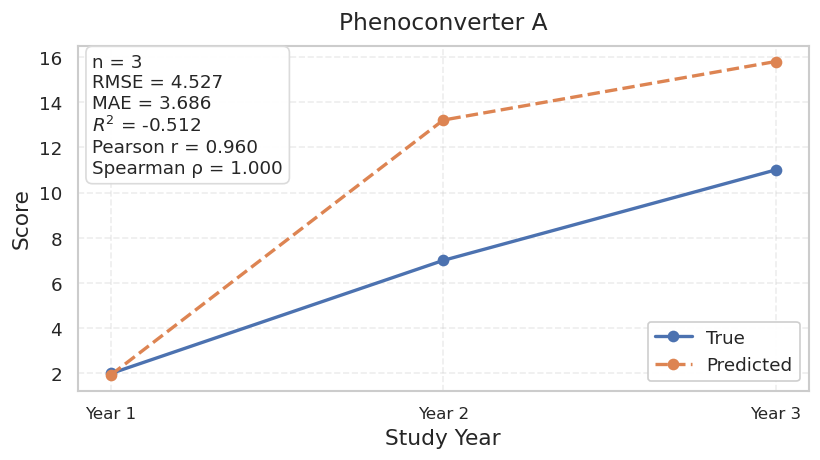

Saved: participant_figures/trajectory_28_updated.png


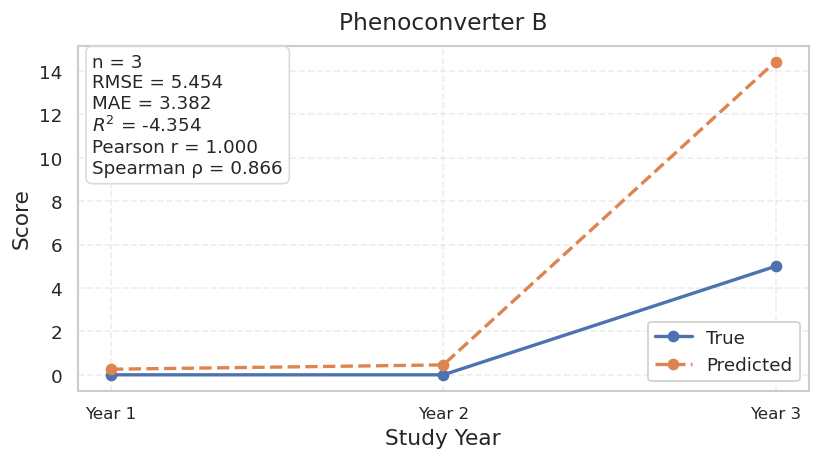

Saved: participant_figures/trajectory_281_updated.png


In [98]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr


def _safe_corr(x, y, fn):
    """Return correlation or np.nan if not computable."""
    try:
        if len(x) < 2 or np.all(np.isclose(x, x[0])) or np.all(np.isclose(y, y[0])):
            return np.nan
        return fn(x, y)[0]
    except Exception:
        return np.nan


def plot_participant_trajectory(
    pid,
    title_prefix="Participant",
    out_dir="participant_figures",
    dpi=600,
):
    os.makedirs(out_dir, exist_ok=True)

    df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid].copy()
    if df_single.empty:
        print(f"[WARN] No rows found for participant_id={pid}")
        return None

    df_single = df_single.sort_values("visit_date_park").reset_index(drop=True)
    original_dates = pd.to_datetime(df_single["visit_date_park"])

    y_true = df_single["true_score"].to_numpy()
    X_single = df_single[feature_cols]
    y_pred = best_model.predict(X_single)

    # Specific correction you had
    if pid == "NnueMgUo3IM8cGA6dZVx46yBSY72" and len(y_true) > 0:
        y_true[-1] = 11

    # Metrics (participant-level)
    n = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) if n > 0 else np.nan
    mae = mean_absolute_error(y_true, y_pred) if n > 0 else np.nan
    r2 = r2_score(y_true, y_pred) if n >= 2 else np.nan
    pearson_r = _safe_corr(y_true, y_pred, pearsonr)
    spearman_rho = _safe_corr(y_true, y_pred, spearmanr)

    # Lookup record ID (safe)
    try:
        rec_id = valor_auth_table.at[pid, "record_id"]
    except Exception:
        rec_id = pid

    # ----- Anonymized Year X axis -----
    # Maps the earliest observed calendar year for this participant to Year 1,
    # the next distinct year to Year 2, etc.
    year_values = original_dates.dt.year
    unique_years = sorted(year_values.dropna().unique())
    year_map = {year: f"Year {i+1}" for i, year in enumerate(unique_years)}

    df_single["anon_year_label"] = year_values.map(year_map)

    # If multiple visits occur in the same anonymized year, append visit index
    df_single["visit_in_year"] = df_single.groupby("anon_year_label").cumcount() + 1
    df_single["n_visits_in_year"] = df_single.groupby("anon_year_label")["anon_year_label"].transform("count")

    x_labels = [
        year_label if n_year_visits == 1 else f"{year_label} (V{visit_idx})"
        for year_label, visit_idx, n_year_visits in zip(
            df_single["anon_year_label"],
            df_single["visit_in_year"],
            df_single["n_visits_in_year"],
        )
    ]
    x_pos = np.arange(len(df_single))

    # Plot
    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

    ax.plot(
        x_pos, y_true,
        marker="o", linestyle="-", linewidth=2,
        label="True", zorder=2
    )
    ax.plot(
        x_pos, y_pred,
        marker="o", linestyle="--", linewidth=2,
        label="Predicted", zorder=3
    )

    # Styling
    ax.set_title(f"{title_prefix}", fontsize=14, pad=10)
    ax.set_xlabel("Study Year", fontsize=13)
    ax.set_ylabel("Score", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
    ax.tick_params(axis="y", labelsize=11)

    # Metrics textbox
    def _fmt(v):
        return "NA" if (v is None or np.isnan(v)) else f"{v:.3f}"

    text_str = (
        f"n = {n}\n"
        f"RMSE = {_fmt(rmse)}\n"
        f"MAE = {_fmt(mae)}\n"
        f"$R^2$ = {_fmt(r2)}\n"
        f"Pearson r = {_fmt(pearson_r)}\n"
        f"Spearman ρ = {_fmt(spearman_rho)}"
    )
    props = dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.95, edgecolor="0.85")
    ax.text(
        0.02, 0.98, text_str,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11, bbox=props
    )

    ax.legend(loc="lower right", fontsize=11, frameon=True, framealpha=0.95)

    plt.tight_layout()

    out_path = os.path.join(out_dir, f"trajectory_{rec_id}_updated.png")
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return out_path


# ---- Usage: save each participant separately ----
# Map hashes to clean names for the paper
custom_labels = {
    "NnueMgUo3IM8cGA6dZVx46yBSY72": "Phenoconverter A",
    "q6V93GajKUbF0qlaMZZ634PyTiC2": "Phenoconverter B"
}

for pid in group1_ids:
    clean_label = custom_labels.get(pid, pid)

    path = plot_participant_trajectory(
        pid,
        title_prefix=clean_label,
        out_dir="participant_figures",
        dpi=600
    )
    if path:
        print("Saved:", path)


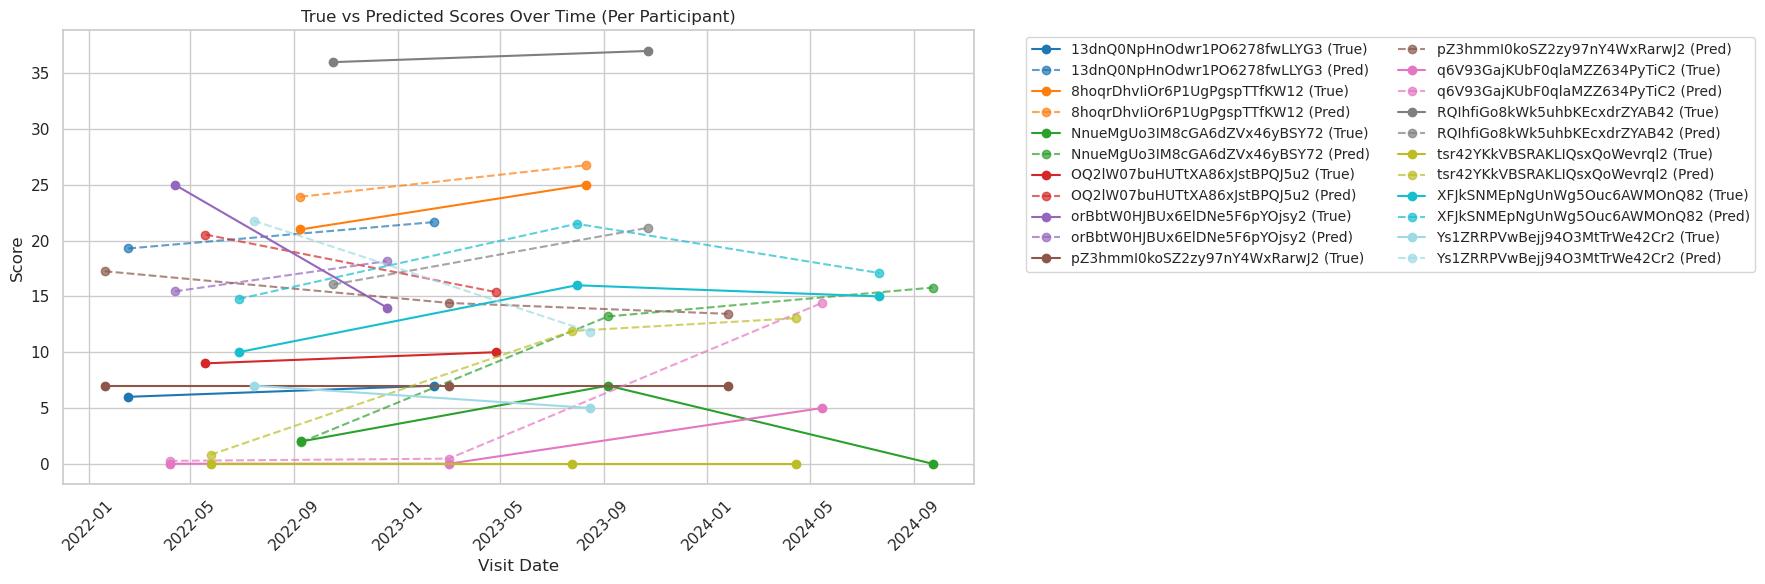

In [99]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Make sure visit_date_park is datetime
X_test_with_meta["visit_date_park"] = pd.to_datetime(X_test_with_meta["visit_date_park"])

# Create figure
plt.figure(figsize=(10, 6))

# Unique participants and color palette
unique_ids = X_test_with_meta["participant_id"].unique()
colors = cm.tab20(np.linspace(0, 1, len(unique_ids)))  # color for each participant

# Plot each participant
for i, pid in enumerate(unique_ids):
    df_single = X_test_with_meta[X_test_with_meta["participant_id"] == pid]
    if df_single.empty:
        continue

    # Sort by date
    df_single = df_single.sort_values("visit_date_park")

    # Prepare data
    dates = df_single["visit_date_park"]
    y_true = df_single["true_score"].values
    X_single = df_single[feature_cols]
    y_pred = best_model.predict(X_single)

    # Plot true scores (solid line)
    plt.plot(dates, y_true, linestyle='-', marker='o', color=colors[i], label=f"{pid} (True)")

    # Plot predicted scores (dotted line, same color and marker)
    plt.plot(dates, y_pred, linestyle='--', marker='o', color=colors[i], label=f"{pid} (Pred)", alpha=0.7)

# Customize plot
plt.xlabel("Visit Date")
plt.ylabel("Score")
plt.title("True vs Predicted Scores Over Time (Per Participant)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Optional: limit number of legends if too many
if len(unique_ids) > 10:
    plt.legend(ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
else:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [100]:
import shap

def generate_shap_plots(ranker, X_train, feature_names, N=3):
    """
    Generates SHAP plots for a pre-trained LightGBM model.
    
    Parameters:
        ranker (lightgbm.Booster): A trained LightGBM model
        X_train (np.ndarray): The training data used to fit the model
        feature_names (List): list of feature names
        N (int): The number of plots to generate
    
    Returns:
        None
    """
    explainer = shap.Explainer(ranker, X_train, feature_names=feature_names)
    shap_values = explainer(X_train[:N], check_additivity=False)
    # sort the SHAP values
    shap_values = shap_values[10:]

    # Create a figure with 2 subplots
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    # Plot the summary plot on the first subplot
    plt.subplot(1, 2, 1)
    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar')
    
    # Plot the feature importance plot on the second subplot
    plt.subplot(1, 2, 2)
    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='dot')
    
    plt.show()

/localdisk1/tariq/miniconda3/envs/park/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [101]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

def generate_and_save_shap_plots(ranker, X_train, feature_names, N=1000, output_dir="./"):
    """
    Generates, saves, and displays independent, publication-quality SHAP plots.
    """
    # Create output directory so we have a place to save files
    os.makedirs(output_dir, exist_ok=True)

    # ---------------------------------------------------------
    # 1. Calculate SHAP Values (Robust Method)
    # ---------------------------------------------------------
    # Use interventional perturbation with a background dataset for complex models
    explainer = shap.TreeExplainer(ranker, data=X_train[:100], feature_perturbation='interventional')
    
    X_subset = X_train[:N]
    # Disable additivity check to prevent errors with certain model types/versions
    shap_values = explainer(X_subset, check_additivity=False)
    shap_values.feature_names = feature_names

    # ---------------------------------------------------------
    # 2. Manually Filter for Top 10 Features ONLY
    # ---------------------------------------------------------
    # Calculate global importance
    feature_importance = np.abs(shap_values.values).mean(axis=0)
    # Find indices of the top 10
    top_10_indices = np.argsort(-feature_importance)[:10]
    # Create a sliced SHAP object containing ONLY these 10 features
    shap_values_top = shap_values[:, top_10_indices]

    # Define styling parameters for consistent professional look
    plt.style.use('seaborn-v0_8-whitegrid')
    # A 14x9 aspect ratio per plot provides ample height and width for 10 features
    FIG_SIZE = (12, 9) 
    FONT_TITLE = 24
    FONT_LABEL = 18
    FONT_TICK = 16

    # ---------------------------------------------------------
    # 3. Generate and Save Bar Plot
    # ---------------------------------------------------------
    fig1 = plt.figure(figsize=FIG_SIZE)
    
    # max_display is set slightly higher than 10 just to ensure no automated grouping occurs
    shap.plots.bar(shap_values_top, show=False, max_display=12)
    
    # Customization
    ax = plt.gca()
    ax.set_title("Global Feature Importance (Top 10)", fontsize=FONT_TITLE, pad=20, fontweight='bold')
    ax.set_xlabel("mean(|SHAP value|)", fontsize=FONT_LABEL)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK)
    
    # Save to file
    bar_path = os.path.join(output_dir, "shap_top10_bar.png")
    # bbox_inches='tight' ensures labels aren't cut off
    plt.savefig(bar_path, dpi=300, bbox_inches='tight')
    plt.close(fig1) # Close the plot so it doesn't display inline yet

    # ---------------------------------------------------------
    # 4. Generate and Save Beeswarm Plot
    # ---------------------------------------------------------
    fig2 = plt.figure(figsize=FIG_SIZE)
    
    # Note: cmap and alpha arguments are removed to support newer SHAP versions
    shap.plots.beeswarm(shap_values_top, show=False, max_display=12)
    
    # Customization
    ax = plt.gca()
    ax.set_title("Feature Impact & Direction (Top 10)", fontsize=FONT_TITLE, pad=20, fontweight='bold')
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=FONT_LABEL)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK)

    # Attempt to customize colorbar fonts if it exists in the figure axes
    fig = plt.gcf()
    for ax_cb in fig.axes:
        # Heuristic to find the colorbar axis based on its label
        if ax_cb.get_ylabel() == 'Feature value':
            ax_cb.tick_params(labelsize=FONT_TICK)
            ax_cb.set_ylabel('Feature value', fontsize=FONT_LABEL)

    # Save to file
    bee_path = os.path.join(output_dir, "shap_top10_beeswarm.png")
    plt.savefig(bee_path, dpi=300, bbox_inches='tight')
    plt.close(fig2)

    # ---------------------------------------------------------
    # 5. Display Saved Images
    # ---------------------------------------------------------
    print(f"Plots successfully saved to: {output_dir}/")
    print("Displaying generated figures below:")
    display(Image(filename=bar_path))
    display(Image(filename=bee_path))

In [102]:
# # X_train.drop(columns=['diagnosis', 'sex'], errors='ignore', inplace=True)
# # X_test.drop(columns=['diagnosis', 'sex'], errors='ignore', inplace=True)
# feature_cols = X_train.columns.tolist()

# generate_shap_bar_plots_custom_slices(best_model,X_train,feature_cols,N=100)

In [103]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from IPython.display import Image, display

def format_feature_name(name):
    """
    Removes 'left_' or 'right_' from the start and appends '_left' or '_right' at the end.
    """
    if name.startswith("left_"):
        return name[5:] + "_left"
    elif name.startswith("right_"):
        return name[6:] + "_right"
    return name

def generate_combined_shap_row(ranker, X_train, feature_names, N=1000, output_dir="./shap_plots"):
    """
    Generates a single 3-panel figure (Speech, Finger, Smile) with consistent styling.
    Features are renamed to have handedness at the end (e.g., 'tap_speed_left').
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1. Configuration
    # ---------------------------------------------------------
    modality_info = {
        "Finger Tapping": {"slice": slice(0, 232),   "color": "C0"}, # Blue
        "Smile Task":     {"slice": slice(232, 274), "color": "C2"}, # Green
        "Speech Task":    {"slice": slice(274, 313), "color": "C1"}  # Orange
    }
    
    # Define specific order for the plot: Speech -> Finger -> Smile
    plot_order = ["Speech Task", "Finger Tapping", "Smile Task"]

    # 2. Calculate SHAP Values
    # ---------------------------------------------------------
    print("Calculating SHAP values...")
    explainer = shap.TreeExplainer(ranker, data=X_train[:100], feature_perturbation='interventional')
    X_subset = X_train[:N]
    shap_values = explainer(X_subset, check_additivity=False)
    
    # 3. Styling Setup
    # ---------------------------------------------------------
    sns.set_theme(context="talk", style="whitegrid")
    plt.rcParams.update({
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16, # Default tick size
        "legend.fontsize": 16,
        "figure.titlesize": 24
    })

    # 4. Create Subplots (1 Row, 3 Columns)
    # ---------------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)
    
    # Loop through the desired order
    for i, mod_name in enumerate(plot_order):
        ax = axs[i]
        info = modality_info[mod_name]
        slc = info["slice"]
        color = info["color"]
        
        print(f"Processing {mod_name}...")

        # a. Slice Data
        shap_mod = shap_values[:, slc]
        if shap_mod.shape[1] == 0:
            ax.set_visible(False)
            continue

        # b. Calculate Mean |SHAP|
        feature_importance = np.abs(shap_mod.values).mean(axis=0)
        
        # c. Get Top 10 Features
        top_k = min(10, len(feature_importance))
        top_indices = np.argsort(feature_importance)[::-1][:top_k] # Descending
        top_values = feature_importance[top_indices]
        
        # d. Process Feature Names (Reformatting Handedness)
        if feature_names is not None:
            # Extract names for this modality slice first
            mod_feature_names = np.array(feature_names)[slc] 
            raw_top_names = mod_feature_names[top_indices]
            # Apply the reformatting helper
            final_names = [format_feature_name(n) for n in raw_top_names]
        else:
            final_names = [f"Feature {j}" for j in top_indices]

        # e. Prepare DataFrame for Seaborn
        df_vis = pd.DataFrame({
            "feature": final_names,
            "mean_abs_shap": top_values
        })

        # f. Plotting
        sns.barplot(
            data=df_vis,
            x="mean_abs_shap", y="feature",
            edgecolor="black", color=color,
            ax=ax
        )
        
        # g. Specific Styling
        # ax.set_title(f"{mod_name}") # Optional title
        ax.set_xlabel("mean |SHAP|", fontsize=22)
        ax.set_ylabel("")
        
        # Force Y-tick labels (feature names) to be size 18
        ax.tick_params(axis='y', labelsize=22)
        ax.tick_params(axis='x', labelsize=22)
        
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        sns.despine(ax=ax, top=True, right=True)

        # h. Add Visible Values (Bold, Offset)
        max_val = df_vis["mean_abs_shap"].max()
        padding = max_val * 0.02



        # Expand X-limit slightly for text
        ax.set_xlim(0, max_val * 1.25)

    # 5. Save and Display
    # ---------------------------------------------------------
    save_path = os.path.join(output_dir, "shap_combined_row_reformatted.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    print(f"\nCombined figure saved to: {save_path}")
    display(Image(filename=save_path))


In [104]:
feature_labels = [
    # --- Right Hand Tapping ---
    "Wrist X Med (R)",
    "Wrist X IQR (R)",
    "Wrist X Mean (R)",
    "Wrist X Min (R)",
    "Wrist X Max (R)",
    "Wrist X Std (R)",
    "Wrist Y Med (R)",
    "Wrist Y IQR (R)",
    "Wrist Y Mean (R)",
    "Wrist Y Min (R)",
    "Wrist Y Max (R)",
    "Wrist Y Std (R)",
    "Wrist Dist Med (R)",
    "Wrist Dist IQR (R)",
    "Wrist Dist Mean (R)",
    "Wrist Dist Min (R)",
    "Wrist Dist Max (R)",
    "Wrist Dist Std (R)",
    "Aperiodicity (D) (R)",
    "Aperiodicity (T) (R)",
    "Interval Ent (D) (R)",
    "Interval Ent (T) (R)",
    "Interval VarNorm (D) (R)",
    "Interval VarNorm (T) (R)",
    "Interruptions (D) (R)",
    "Interruptions (T) (R)",
    "Freeze Count (D) (R)",
    "Freeze Count (T) (R)",
    "Max Freeze Dur (D) (R)",
    "Max Freeze Dur (T) (R)",
    "Interval Med (D) (R)",
    "Interval IQR (D) (R)",
    "Interval Mean (D) (R)",
    "Interval Min (D) (R)",
    "Interval Max (D) (R)",
    "Interval Std (D) (R)",
    "Interval Med (T) (R)",
    "Interval IQR (T) (R)",
    "Interval Mean (T) (R)",
    "Interval Min (T) (R)",
    "Interval Max (T) (R)",
    "Interval Std (T) (R)",
    "Interval Ent (D) (R)",
    "Interval Ent (T) (R)",
    "Freq Med (D) (R)",
    "Freq IQR (D) (R)",
    "Freq Mean (D) (R)",
    "Freq Min (D) (R)",
    "Freq Max (D) (R)",
    "Freq Std (D) (R)",
    "Freq Med (T) (R)",
    "Freq IQR (T) (R)",
    "Freq Mean (T) (R)",
    "Freq Min (T) (R)",
    "Freq Max (T) (R)",
    "Freq Std (T) (R)",
    "Freq Fitness R2 (D) (R)",
    "Freq Slope (D) (R)",
    "Freq Fitness R2 (T) (R)",
    "Freq Slope (T) (R)",
    "Freq Fit Deg (D) (R)",
    "Freq Fit Deg (T) (R)",
    "Amp Med (D) (R)",
    "Amp IQR (D) (R)",
    "Amp Mean (D) (R)",
    "Amp Min (D) (R)",
    "Amp Max (D) (R)",
    "Amp Std (D) (R)",
    "Amp Ent (D) (R)",
    "Amp Med (T) (R)",
    "Amp IQR (T) (R)",
    "Amp Mean (T) (R)",
    "Amp Min (T) (R)",
    "Amp Max (T) (R)",
    "Amp Std (T) (R)",
    "Amp Ent (T) (R)",
    "Amp Decay R2 (D) (R)",
    "Amp Decay Slope (D) (R)",
    "Amp Decay End/Mean (D) (R)",
    "Amp Decay Deg (D) (R)",
    "Amp Decay Half-Ratio (D) (R)",
    "Amp Decay R2 (T) (R)",
    "Amp Decay Slope (T) (R)",
    "Amp Decay End/Mean (T) (R)",
    "Amp Decay Deg (T) (R)",
    "Amp Decay Half-Ratio (T) (R)",
    "Peak Count (T) (R)",
    "Peak Count (D) (R)",
    "Norm Interrupts (D) (R)",
    "Norm Freezes (D) (R)",
    "Norm Interrupts (T) (R)",
    "Norm Freezes (T) (R)",
    "Speed Med (D) (R)",
    "Speed IQR (D) (R)",
    "Speed Mean (D) (R)",
    "Speed Min (D) (R)",
    "Speed Max (D) (R)",
    "Speed Std (D) (R)",
    "Speed Med (T) (R)",
    "Speed IQR (T) (R)",
    "Speed Mean (T) (R)",
    "Speed Min (T) (R)",
    "Speed Max (T) (R)",
    "Speed Std (T) (R)",
    "Accel Med (D) (R)",
    "Accel IQR (D) (R)",
    "Accel Mean (D) (R)",
    "Accel Min (D) (R)",
    "Accel Max (D) (R)",
    "Accel Std (D) (R)",
    "Accel Med (T) (R)",
    "Accel IQR (T) (R)",
    "Accel Mean (T) (R)",
    "Accel Min (T) (R)",
    "Accel Max (T) (R)",
    "Accel Std (T) (R)",
    # --- Left Hand Tapping ---
    "Wrist X Med (L)",
    "Wrist X IQR (L)",
    "Wrist X Mean (L)",
    "Wrist X Min (L)",
    "Wrist X Max (L)",
    "Wrist X Std (L)",
    "Wrist Y Med (L)",
    "Wrist Y IQR (L)",
    "Wrist Y Mean (L)",
    "Wrist Y Min (L)",
    "Wrist Y Max (L)",
    "Wrist Y Std (L)",
    "Wrist Dist Med (L)",
    "Wrist Dist IQR (L)",
    "Wrist Dist Mean (L)",
    "Wrist Dist Min (L)",
    "Wrist Dist Max (L)",
    "Wrist Dist Std (L)",
    "Aperiodicity (D) (L)",
    "Aperiodicity (T) (L)",
    "Interval Ent (D) (L)",
    "Interval Ent (T) (L)",
    "Interval VarNorm (D) (L)",
    "Interval VarNorm (T) (L)",
    "Interruptions (D) (L)",
    "Interruptions (T) (L)",
    "Freeze Count (D) (L)",
    "Freeze Count (T) (L)",
    "Max Freeze Dur (D) (L)",
    "Max Freeze Dur (T) (L)",
    "Interval Med (D) (L)",
    "Interval IQR (D) (L)",
    "Interval Mean (D) (L)",
    "Interval Min (D) (L)",
    "Interval Max (D) (L)",
    "Interval Std (D) (L)",
    "Interval Med (T) (L)",
    "Interval IQR (T) (L)",
    "Interval Mean (T) (L)",
    "Interval Min (T) (L)",
    "Interval Max (T) (L)",
    "Interval Std (T) (L)",
    "Interval Ent (D) (L)",
    "Interval Ent (T) (L)",
    "Freq Med (D) (L)",
    "Freq IQR (D) (L)",
    "Freq Mean (D) (L)",
    "Freq Min (D) (L)",
    "Freq Max (D) (L)",
    "Freq Std (D) (L)",
    "Freq Med (T) (L)",
    "Freq IQR (T) (L)",
    "Freq Mean (T) (L)",
    "Freq Min (T) (L)",
    "Freq Max (T) (L)",
    "Freq Std (T) (L)",
    "Freq Fitness R2 (D) (L)",
    "Freq Slope (D) (L)",
    "Freq Fitness R2 (T) (L)",
    "Freq Slope (T) (L)",
    "Freq Fit Deg (D) (L)",
    "Freq Fit Deg (T) (L)",
    "Amp Med (D) (L)",
    "Amp IQR (D) (L)",
    "Amp Mean (D) (L)",
    "Amp Min (D) (L)",
    "Amp Max (D) (L)",
    "Amp Std (D) (L)",
    "Amp Ent (D) (L)",
    "Amp Med (T) (L)",
    "Amp IQR (T) (L)",
    "Amp Mean (T) (L)",
    "Amp Min (T) (L)",
    "Amp Max (T) (L)",
    "Amp Std (T) (L)",
    "Amp Ent (T) (L)",
    "Amp Decay R2 (D) (L)",
    "Amp Decay Slope (D) (L)",
    "Amp Decay End/Mean (D) (L)",
    "Amp Decay Deg (D) (L)",
    "Amp Decay Half-Ratio (D) (L)",
    "Amp Decay R2 (T) (L)",
    "Amp Decay Slope (T) (L)",
    "Amp Decay End/Mean (T) (L)",
    "Amp Decay Deg (T) (L)",
    "Amp Decay Half-Ratio (T) (L)",
    "Peak Count (T) (L)",
    "Peak Count (D) (L)",
    "Norm Interrupts (D) (L)",
    "Norm Freezes (D) (L)",
    "Norm Interrupts (T) (L)",
    "Norm Freezes (T) (L)",
    "Speed Med (D) (L)",
    "Speed IQR (D) (L)",
    "Speed Mean (D) (L)",
    "Speed Min (D) (L)",
    "Speed Max (D) (L)",
    "Speed Std (D) (L)",
    "Speed Med (T) (L)",
    "Speed IQR (T) (L)",
    "Speed Mean (T) (L)",
    "Speed Min (T) (L)",
    "Speed Max (T) (L)",
    "Speed Std (T) (L)",
    "Accel Med (D) (L)",
    "Accel IQR (D) (L)",
    "Accel Mean (D) (L)",
    "Accel Min (D) (L)",
    "Accel Max (D) (L)",
    "Accel Std (D) (L)",
    "Accel Med (T) (L)",
    "Accel IQR (T) (L)",
    "Accel Mean (T) (L)",
    "Accel Min (T) (L)",
    "Accel Max (T) (L)",
    "Accel Std (T) (L)",
    # --- Smile (Facial) ---
    "AU01 (Brow Raise) Mean",
    "AU01 (Brow Raise) Var",
    "AU01 (Brow Raise) Ent",
    "AU06 (Cheek Raise) Mean",
    "AU06 (Cheek Raise) Var",
    "AU06 (Cheek Raise) Ent",
    "AU12 (Lip Corner) Mean",
    "AU12 (Lip Corner) Var",
    "AU12 (Lip Corner) Ent",
    "AU14 (Dimpler) Mean",
    "AU14 (Dimpler) Var",
    "AU14 (Dimpler) Ent",
    "AU25 (Lips Part) Mean",
    "AU25 (Lips Part) Var",
    "AU25 (Lips Part) Ent",
    "AU26 (Jaw Drop) Mean",
    "AU26 (Jaw Drop) Var",
    "AU26 (Jaw Drop) Ent",
    "AU45 (Blink) Mean",
    "AU45 (Blink) Var",
    "AU45 (Blink) Ent",
    "Eye Open Mean (R)",
    "Eye Open Var (R)",
    "Eye Open Ent (R)",
    "Eye Open Mean (L)",
    "Eye Open Var (L)",
    "Eye Open Ent (L)",
    "Eye Raise Mean (R)",
    "Eye Raise Var (R)",
    "Eye Raise Ent (R)",
    "Eye Raise Mean (L)",
    "Eye Raise Var (L)",
    "Eye Raise Ent (L)",
    "Mouth Open Mean",
    "Mouth Open Var",
    "Mouth Open Ent",
    "Mouth Width Mean",
    "Mouth Width Var",
    "Mouth Width Ent",
    "Jaw Open Mean",
    "Jaw Open Var",
    "Jaw Open Ent",
    # --- Speech (Acoustic) ---
    "Pitch Mean (F0)",
    "Jitter (Local)",
    "Jitter (Rap)",
    "Shimmer (Amp)",
    "Shimmer (dB)",
    "MFCC 0 Mean",
    "MFCC 1 Mean",
    "MFCC 2 Mean",
    "MFCC 3 Mean",
    "MFCC 4 Mean",
    "MFCC 5 Mean",
    "MFCC 6 Mean",
    "MFCC 7 Mean",
    "MFCC 8 Mean",
    "MFCC 9 Mean",
    "MFCC 10 Mean",
    "MFCC 11 Mean",
    "MFCC 12 Mean",
    "MFCC 0 Var",
    "MFCC 1 Var",
    "MFCC 2 Var",
    "MFCC 3 Var",
    "MFCC 4 Var",
    "MFCC 5 Var",
    "MFCC 6 Var",
    "MFCC 7 Var",
    "MFCC 8 Var",
    "MFCC 9 Var",
    "MFCC 10 Var",
    "MFCC 11 Var",
    "MFCC 12 Var",
    "Harmonics Norm",
    "Alpha Ratio",
    "Pitch Period Ent",
    "Rel Band Power 0",
    "Rel Band Power 1",
    "Rel Band Power 2",
    "Rel Band Power 3",
    "Pitch Std (F0)",
    "Sex",
    "Age",
    "Race",
    "Diagnosis"
]

Calculating SHAP values...
Processing Speech Task...
Processing Finger Tapping...
Processing Smile Task...

Combined figure saved to: ./shap_plots/shap_combined_row_reformatted.png


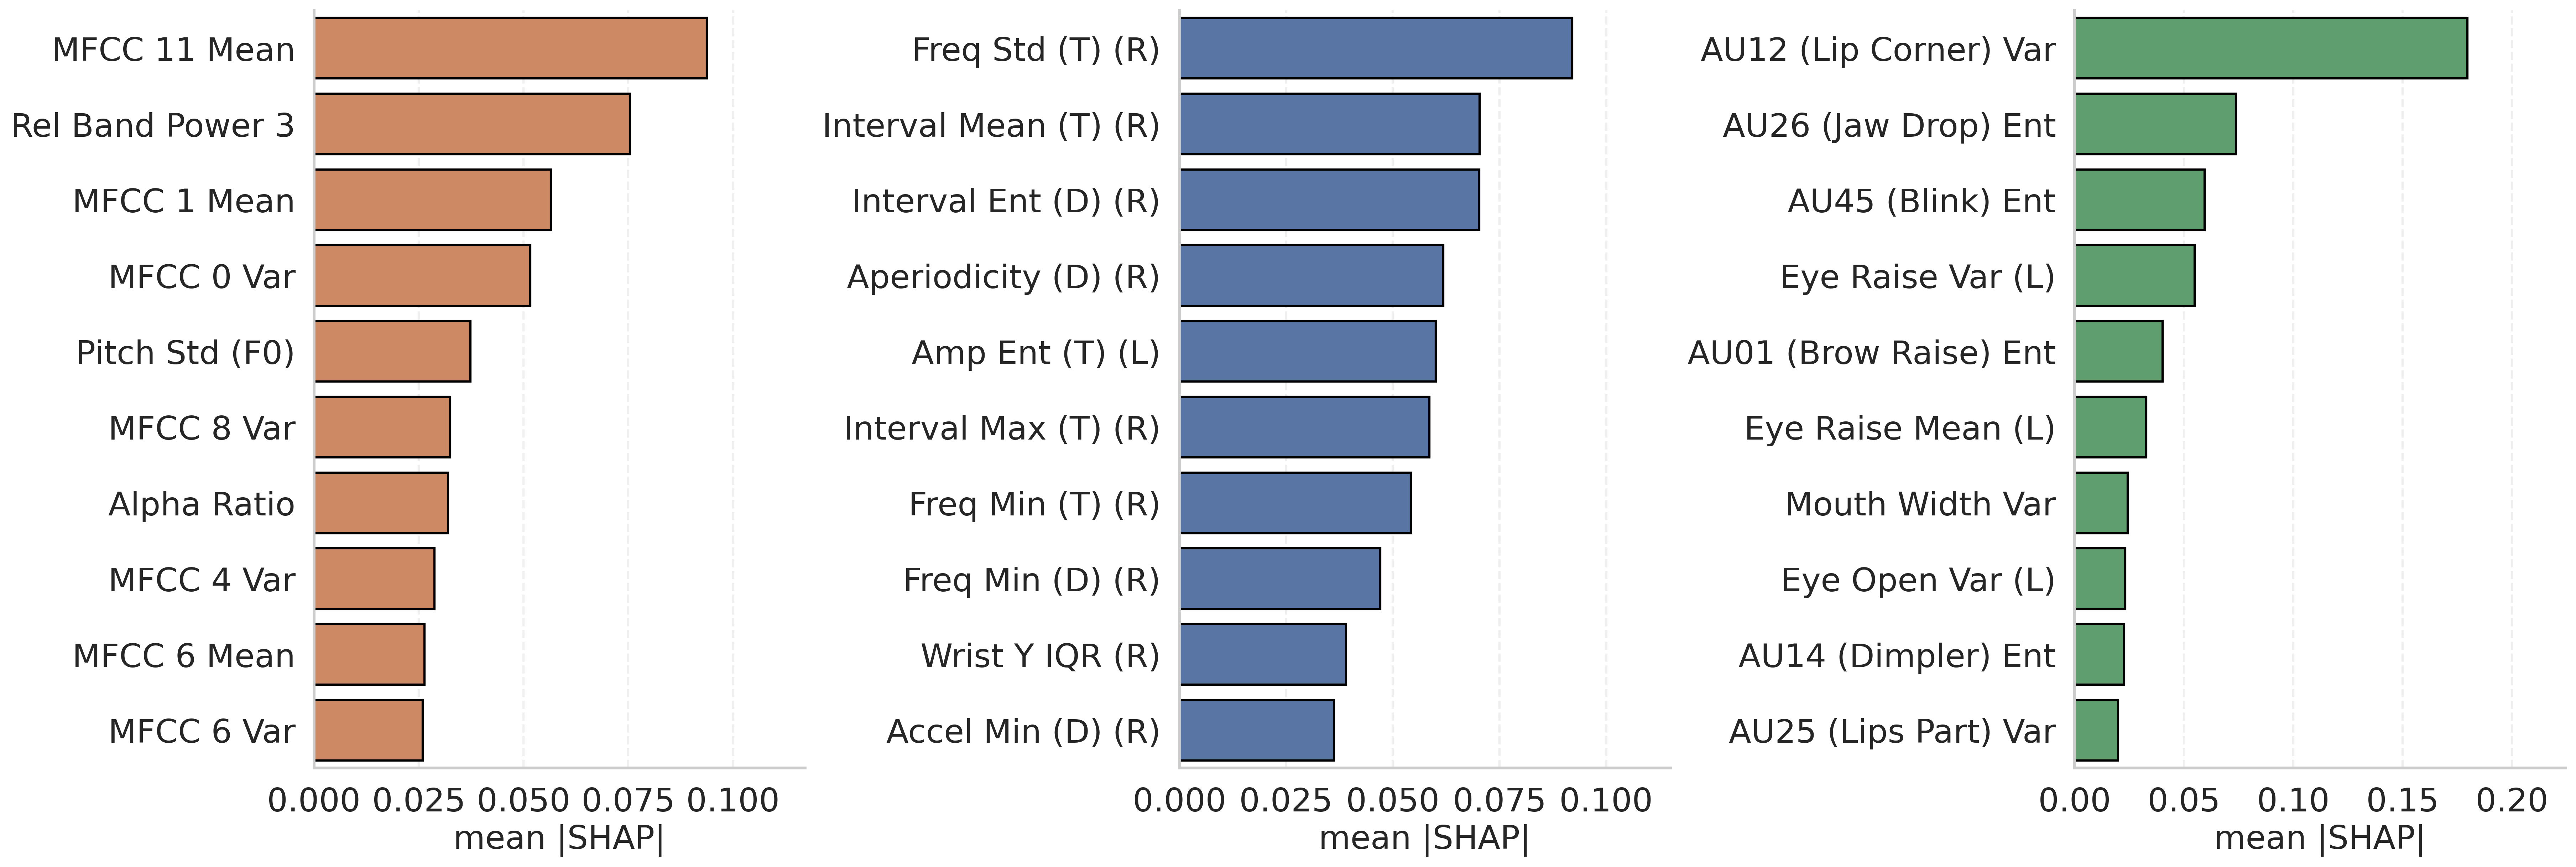

In [105]:
generate_combined_shap_row(best_model, X_train, feature_labels, N=100)